# Анализ юнит-экономики и оптимизация ассортимента НКО на маркетплейсах Ozon и Яндекс Маркет
**Автор:** Гребенкина Наталья<br>
**Дата:** 18 августа 2026 г.

## 1. Бизнес-контекст и цель анализа

**Цель:** Декомпозиция факторов влияния на финансовый результат, выявление структурных утечек прибыли и формирование рекомендаций по оптимизации SKU-матрицы и логистических моделей.

**Описание бизнеса:**  
Компания является НКО, реализующим тематический мерч (одежда, аксессуары, канцелярия, посуда) через маркетплейсы. Продажи имеют выраженный событийный характер, привязанный к календарю донорства (пики в апреле и июне).

**Условия работы с площадками:**
1. **Яндекс Маркет (основная площадка, схема FBY):**
   - Комиссия: 0% (индивидуальная льгота для НКО).
   - Логистика и хранение: 0 руб. (площадка полностью субсидирует доставку до клиента, обратную логистику и размещение на складе, включая хранение >120 дней).
   - Дополнительные расходы: эквайринг (~0.1%), утилизация брака (100–500 руб./мес.).
   - Ассортимент: 107 активных SKU.

2. **Ozon (площадка-витрина, схема FBO):**
   - Комиссия: 1% (льготная ставка для НКО).
   - Логистика и хранение: оплачиваются доставка до клиента, обратная логистика, первичная приемка и **размещение на складе свыше 120 дней**.
   - Ассортимент: сокращен до 66 активных SKU для минимизации затрат на хранение неликвида.

**Специфика SKU:**  
Товары с одинаковой базовой ценой и себестоимостью, но разными цветами и размерами (например, футболки), технически являются множеством отдельных SKU, объединенных в одну карточку. Алгоритмы площадок применяют скидки точечно к конкретным вариациям, что делает усредненную цену по "карточке" нерепрезентативной. Анализ ведется строго на уровне индивидуального SKU.

## 2. Executive Summary

**Яндекс Маркет — основная площадка.** Выручка в 2.5 раза выше, прибыль — в 3.6 раза, доля сборов — 2.4% против 18.8% на Ozon. Логистика и хранение полностью субсидируются: 11 из 16 статей затрат равны нулю. Убыточных SKU нет.

**Ozon — зона риска.** Основная утечка прибыли — хранение (31% сборов) и логистика (26%). 8 убыточных SKU съедают 19% прибыли. Причина — превышение 120 дней бесплатного хранения. Товары с низкой оборачиваемостью накапливают затраты, которые превышают маржу от продажи.

**Цена не управляет спросом.** Корреляция цены и объема: Ozon -0.37, Маркет -0.07. Экстремальный разброс цен (до 617%) — следствие вынужденных распродаж склада, а не ценовой стратегии.

**Ассортиментное ядро.** 9 SKU на Ozon и 20 на Маркете генерируют основную прибыль (браслеты, значки, жмяка-эспандер). Остальной ассортимент — поддерживающий, требует минимальных остатков.


**Ключевая рекомендация**<br>
Сместить фокус с ценообразования на управление складскими остатками. Внедрить систему раннего оповещения по товарам, теряющим оборачиваемость, и перераспределить ассортимент: Ozon — только для высокомаржинальных товаров с быстрой оборачиваемостью, Маркет — основная площадка для масштабирования.

## 3. Допущения, методологические решения

### 3.1. Допущения по данным


1. **Отсутствие истории цен в корзине:** API не позволяет выгрузить цену, которую видел покупатель до персональных скидок. Анализ ценообразования построен на фактической средней цене реализации (ASP = Выручка / Выкупы).
2. **Отсутствие исторических данных по складским остаткам:** Анализ проведен на основе продаж и начислений. Невозможно точно оценить оборачиваемость (overstock) или периоды out-of-stock (OOS). Низкие продажи могут быть следствием как отсутствия спроса, так и отсутствия товара на складе.
3. **Расчетное распределение сборов (Яндекс Маркет):** Отчеты не содержат детализации сервисных расходов по конкретным SKU внутри мульти-товарного заказа. Распределение выполнено пропорционально выручке товара в заказе.

### 3.2. Методологические решения

- **Корректировка технического сбоя Ozon:** В исторических данных зафиксировано списание комиссии 33% вместо льготной 1%. Для целей анализа юнит-экономики и сегментации показатель комиссии принудительно скорректирован до 1% от выручки, чтобы оценить истинную экономическую эффективность товара, исключая разовые ошибки площадки.

- **Расчетное распределение сборов на Маркете:** Отчеты не содержат детализации сервисных расходов по SKU внутри мульти-товарного заказа. Распределение выполнено пропорционально выручке товара в заказе. Метод корректен для агрегированной аналитики, но может содержать погрешность для отдельных заказов.

- **Отказ от классического ABC-анализа:** В мерче массовые дешевые товары (значки) критически важны для воронки, а редкие дорогие (термостаканы) формируют имидж. Применена многомерная сегментация: `margin_health` × `intensity_level` × `sales_presence`.

- **Анализ ценообразования только для топ-SKU:** Для товаров с интенсивностью продаж менее 3 шт./мес. статистическая выборка недостаточна для корреляции цены и объема. Выводы по эластичности спроса релевантны только для SKU с высоким и стабильным спросом.

- **Период анализа:** 12 месяцев (июль 2025 – июнь 2026). Июль 2026 исключен как неполный месяц.

## 4. Технический блок
В этом разделе собраны импорты библиотек и вспомогательные функции, которые используются для построения графиков и расчёта ключевых метрик в следующих блоках анализа. Это позволяет избежать дублирования кода, упрощает внесение изменений и делает ноутбук более читаемым.

In [1]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Настройки отображения
pd.set_option('display.float_format', lambda x: f'{x:.2f}')
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

In [3]:
def optimize_dtypes(df):
    """Применяет оптимальные типы данных к датафрейму"""
    
    # Integer колонки
    for col in int_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col].astype('Int64'), downcast='integer')
            
    # Float колонки
    for col in float_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], downcast='float').round(2)
       
    
    # Category колонки (SKU и справочники)
    for col in category_cols:
        if col in df.columns:
            df[col] = df[col].astype('category')

    # Period колонки
    for col in period_cols:
        if col in df.columns:
            try:
                df[col] = pd.to_datetime(df[col], format='%d.%m.%Y').dt.to_period('M')
            except:
                pass

    # Приведение order_id к корректному виду
    if 'order_id' in df.columns:
        df['order_id'] = df['order_id'].astype(str).str.replace(r'\.0$', '', regex=True)

In [4]:
# Создаем функцию для вывода краткой информации
def dataframe_summary(df):
    """выводит краткую справку по датафрейму"""
    summary = pd.DataFrame({'column': df.columns,
                            'dtype': df.dtypes.values,
                            'non_null': df.count().values,
                            'nulls': df.isnull().sum().values,
                            'nulls_%': (df.isnull().sum() / len(df) * 100).round(2).values,
                            'unique': df.nunique().values})
    return summary

In [5]:
def calc_marginality(profit_col, revenue_col):
    """Безопасный расчет маржинальности с обработкой inf/nan"""
    return (profit_col / revenue_col).replace([np.inf, -np.inf], np.nan).round(3)

In [6]:
# Сегментация товаров
def segment_sku(df, 
                margin_col='marginality', 
                intensity_col='intensity', 
                months_col='active_months',
                margin_bins=None,
                margin_labels=None,
                intensity_threshold=None,
                sales_presence_bins=None,
                sales_presence_labels=None):
    """
    Сегментация SKU по методологии (раздел 3.4).
    """

        # Подставляем пороги из глобальных констант, если не переданы явно
    if margin_bins is None:
        margin_bins = MARGIN_BINS
    if margin_labels is None:
        margin_labels = MARGIN_LABELS
    if intensity_threshold is None:
        intensity_threshold = INTENSITY_THRESHOLD
    if sales_presence_bins is None:
        sales_presence_bins = SALES_PRESENCE_BINS
    if sales_presence_labels is None:
        sales_presence_labels = SALES_PRESENCE_LABELS
        
    df = df.copy()
    
    # УРОВЕНЬ 1: Маржинальность
    df['margin_health'] = pd.cut(df[margin_col], bins=margin_bins, labels=margin_labels)
    
    # УРОВЕНЬ 2: Интенсивность продаж
    df['intensity_level'] = pd.cut(df[intensity_col], bins=[-np.inf, 0, intensity_threshold, np.inf], labels=['Без продаж', 'Низкая', 'Высокая'])
    
    # УРОВЕНЬ 3: Регулярность заказов
    df['sales_presence'] = pd.cut(df[months_col], bins=sales_presence_bins, labels=sales_presence_labels)
    
    # Финальная сегментация (комбинация всех уровней)
    # Для товаров без продаж — отдельная метка, игнорирующая маржу и регулярность
    df['final_segment'] = np.where(df['intensity_level'] == 'Без продаж',
                                   'Без продаж',
                                   df['margin_health'].astype(str) + ' + ' + df['intensity_level'].astype(str) + ' частота + ' +
                                   df['sales_presence'].astype(str))
    
    return df

In [7]:
def plot_heatmap(pivot_df, title, cmap='RdYlGn', fmt='.0%', vmin=-1, vmax=1, figsize=(14, 8)):
    """Строит heatmap маржинальности с форматированием"""
    fig, ax = plt.subplots(figsize=figsize)
    
    # Приводим к float только числовые колонки
    pivot_clean = pivot_df.select_dtypes(include=['number']).astype(float)
    
    sns.heatmap(pivot_clean, annot=True, fmt=fmt, cmap=cmap, center=0,
                linewidths=0.5, vmin=vmin, vmax=vmax,
                cbar_kws={'label': 'Маржинальность'}, ax=ax)
    
    plt.title(title, fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Период', fontsize=12, fontweight='bold')
    plt.ylabel('Категория', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.grid(False)
    plt.show()

In [8]:
def add_recommendations(df, sku_col='sku_ozon', segment_col='final_segment'):
    """Добавляет колонку с рекомендациями на основе сегментации."""
    df_copy = df.copy()
    df_copy['recommendation'] = ''
    
    # 1. Ядро (держать в наличии) — высокая маржа + высокая частота
    mask_core = df_copy[segment_col].str.contains('Высокая маржа', na=False) & \
                df_copy[segment_col].str.contains('Высокая частота', na=False)
    df_copy.loc[mask_core, 'recommendation'] = 'Ядро (держать в наличии)'
    
    # 2. Повысить цену (тест) — средняя или низкая маржа + высокая частота
    mask_price_test = (df_copy[segment_col].str.contains('Средняя маржа', na=False) | \
                       df_copy[segment_col].str.contains('Низкая маржа', na=False)) & \
                      df_copy[segment_col].str.contains('Высокая частота', na=False)
    df_copy.loc[mask_price_test, 'recommendation'] = 'Повысить цену (тест)'
    
    # 3. Контроль остатков / Вывод вариаций — отрицательная маржа
    mask_price_remove = df_copy[segment_col].str.contains('Отрицательная маржа', na=False)
    df_copy.loc[mask_price_remove, 'recommendation'] = 'Контроль остатков / Вывод вариаций'
    
    # 4. Аудит карточки — товары без продаж
    mask_no_sales = df_copy[segment_col] == 'Без продаж'
    df_copy.loc[mask_no_sales, 'recommendation'] = 'Аудит карточки'
    
    # 5. Ассортимент (1–2 шт.) — все остальные
    mask_assortment = df_copy['recommendation'] == ''
    df_copy.loc[mask_assortment, 'recommendation'] = 'Ассортимент (1–2 шт.)'
    
    return df_copy

In [9]:
def aggregate_platform(df, platform_name):
    """Агрегирует данные по площадкам."""
    return {
        'platform': platform_name,
        'sku_count': len(df),
        'sold': df['sold'].sum(),
        'total_revenue': df['total_revenue'].sum(),
        'cogs': df['cogs'].sum(),
        'total_mp_fees': df['total_mp_fees'].sum(),
        'profit': df['profit'].sum(),
        'margin_pct': (df['profit'].sum() / df['total_revenue'].sum() * 100) if df['total_revenue'].sum() > 0 else 0,
        'fees_pct': (df['total_mp_fees'].sum() / df['total_revenue'].sum() * 100) if df['total_revenue'].sum() > 0 else 0
    }

In [10]:
def heatmap_fees(df, title):
    """Строит heatmap сервисных расходов"""  
    
    fig, ax = plt.subplots(figsize=(16, 8))
  
  
    sns.heatmap(df, 
                annot=True, 
                fmt=',.0f', 
                cmap='RdYlGn_r',
                center=0,
                cbar_kws={'label': 'Затраты (руб.)'},
                linewidths=0.5, 
                ax=ax)
    
    
    plt.title(title,
              fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Период', fontsize=12, fontweight='bold')
    plt.ylabel('Тип начисления', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    
    for text in ax.texts:
        if text.get_text() == '0':
            text.set_text('')
    
    plt.tight_layout()
    plt.show()

## 5. Подготовка данных
Цель этого блока — очистить данные, проверить их целостность.

In [11]:
# Пути к файлам
PATH = r'D:\Projects\Мастерская\DonorSearch\Output\\'
MASTER_PATH = r'D:\Projects\Мастерская\DonorSearch\Материалы\Основное\мастер-файл.csv'

In [12]:
# ЯНДЕКС.МАРКЕТ

# Воронка
funnel_cols = {'Ваш SKU': 'sku_market',
               'Название товара': 'name',
               'Период': 'period',
               'Показы моих товаров, шт.': 'impressions',
               'Добавления в корзину, шт.': 'add_to_cart',
               'Заказанные товары, шт.': 'ordered',
               'Доставлено за период, шт.': 'delivered',
               'Доставлено за период на сумму, ₽': 'revenue',
               'Доля заказанных товаров с бустом, %': 'boost_share'}

market_funnel_df = pd.read_csv(f'{PATH}market_funnel.csv',
                               usecols=list(funnel_cols.keys()))

market_funnel_df.rename(columns=funnel_cols, inplace=True)

print('market_funnel_df загружен')

# Возвращенные товары
return_cols = {'Ваш SKU': 'sku_market',
               'Название товара': 'name',
               'Ваш номер заказа': 'order_id',
               'Количество доставленных, шт.': 'delivered',
               'Возвращено, шт.': 'returned',
               'Дата оформления заказа': 'date_ordered',
               'Дата приёма возврата складом или сортировочным центром': 'date_return_accepted',
               'Цена c НДС без учёта скидок за шт., ₽': 'base_price',
               'Цена с НДС с учётом всех скидок за шт., ₽': 'selling_price',
               'Стоимость всех возвращённых штук с НДС с учётом всех скидок, ₽': 'total_returned_value'}

market_returns_df = pd.read_csv(f'{PATH}market_возвращенные_товары.csv',
                                usecols=list(return_cols.keys()),
                                parse_dates=['Дата оформления заказа', 'Дата приёма возврата складом или сортировочным центром'],
                                dayfirst=True,
                                dtype={'Ваш номер заказа': str})

market_returns_df.rename(columns=return_cols, inplace=True)

print('market_returns_df загружен')


# Доставленные товары
delivered_cols = {'Ваш SKU': 'sku_market',
                  'Название товара': 'name',
                  'Ваш номер заказа': 'order_id',
                  'Количество переданных в доставку, шт.': 'to_delivery',
                  'Доставлено, шт.': 'delivered',
                  'Дата оформления заказа': 'date_ordered',
                  'Дата доставки товара': 'date_delivered',
                  'Цена c НДС без учёта скидок за шт., ₽': 'base_price',
                  'Цена с НДС с учётом всех скидок за шт., ₽': 'selling_price',
                  'Стоимость всех доставленных штук с НДС с учётом всех скидок, ₽': 'total_delivered_value',
                  'Ваша скидка по акции маркетплейса на 1 шт., ₽': 'discount_market',
                  'Ваша скидка по баллам Яндекс.Плюса на 1 шт., ₽': 'discount_plus',
                  'Ваша скидка по бонусам СберСпасибо (за шт.) на 1 шт., ₽': 'discount_sber'}

market_delivered_df = pd.read_csv(f'{PATH}market_доставленные_товары.csv',
                                  usecols=list(delivered_cols.keys()), parse_dates=['Дата оформления заказа', 'Дата доставки товара'],
                                  dayfirst=True,
                                  dtype={'Ваш номер заказа': str})

market_delivered_df.rename(columns=delivered_cols, inplace=True)

print('market_delivered_df загружен')


# Невыкупленные товары
unredeemed_cols = {'Ваш SKU': 'sku_market',
                   'Название товара': 'name',
                   'Ваш номер заказа': 'order_id',
                   'Количество переданных в доставку, шт.': 'to_delivery',
                   'Не выкуплено, шт.': 'unredeemed',
                   'Дата оформления заказа': 'date_ordered',
                   'Дата приёма невыкупа складом или сортировочным центром': 'date_unredeemed_accepted',
                   'Цена c НДС без учёта скидок за шт., ₽': 'base_price',
                   'Цена с НДС с учётом всех скидок за шт., ₽': 'selling_price',
                   'Стоимость всех невыкупленных штук с НДС с учётом всех скидок, ₽': 'total_unredeemed_value'}

market_unredeemed_df = pd.read_csv(f'{PATH}market_невыкупленные_товары.csv',
                                   usecols=list(unredeemed_cols.keys()),
                                   parse_dates=['Дата оформления заказа', 'Дата приёма невыкупа складом или сортировочным центром'],
                                   dayfirst=True,
                                   dtype={'Ваш номер заказа': str})

market_unredeemed_df.rename(columns=unredeemed_cols, inplace=True)

print('market_unredeemed_df загружен')



# Товары в доставке
in_delivery_cols = {'Ваш SKU': 'sku_market',
                    'Название товара': 'name',
                    'Ваш номер заказа': 'order_id',
                    'Количество переданных в доставку, шт.': 'to_delivery',
                    'Дата оформления заказа': 'date_ordered',
                    'Дата передачи товара в доставку': 'date_to_delivery',
                    'Дата доставки товара': 'date_delivered',
                    'Цена c НДС без учёта скидок за шт., ₽': 'base_price',
                    'Цена с НДС с учётом всех скидок за шт., ₽': 'selling_price',
                    'Стоимость всех переданных в доставку штук с НДС с учётом всех скидок, ₽': 'total_to_delivery_value',
                    'Ваша скидка по акции маркетплейса на 1 шт., ₽': 'discount_market',
                    'Ваша скидка по баллам Яндекс.Плюса на 1 шт., ₽': 'discount_plus',
                    'Ваша скидка по бонусам СберСпасибо (за шт.) на 1 шт., ₽': 'discount_sber'}

market_in_delivery_df = pd.read_csv(f'{PATH}market_товары_переданные_в_доставку.csv',
                                    usecols=list(in_delivery_cols.keys()),
                                    parse_dates=['Дата оформления заказа',
                                                 'Дата передачи товара в доставку',
                                                 'Дата доставки товара'],
                                    dayfirst=True,
                                    dtype={'Ваш номер заказа': str})

market_in_delivery_df.rename(columns=in_delivery_cols, inplace=True)

print('market_in_delivery_df загружен')



# Транзакции
transactions_cols = {'Ваш SKU': 'sku_market',
                     'Название товара': 'name',
                     'Модели работы': 'work_model',
                     'Ваш номер заказа': 'order_id',
                     'Дата оформления': 'date_ordered',
                     'Дата доставки заказа': 'date_delivered',
                     'Статус товара': 'status',
                     'Цена продажи (за шт.), ₽': 'selling_price',
                     'Скидка Маркета, если товар участвовал в софинансировании, ₽': 'discount_market_cofinancing',
                     'Другие скидки Маркета (за шт.), ₽': 'discount_market_other',
                     'Сумма платежа': 'payment_amount',
                     'Сумма возврата': 'refund_amount',
                     'Сумма баллов': 'bonus_amount',
                     'Удержанная сумма': 'held_amount'}

market_transactions_df = pd.read_csv(f'{PATH}market_transactions.csv',
                                     usecols=list(transactions_cols.keys()),
                                     parse_dates=['Дата оформления', 'Дата доставки заказа'],
                                     dayfirst=True,
                                     dtype={'Ваш номер заказа': str})

market_transactions_df.rename(columns=transactions_cols, inplace=True)

print('market_transactions_df загружен')


# Маржа
margin_cols = {'Модели работы': 'work_model',
               'Ваш номер заказа': 'order_id',
               'Статус заказа': 'order_status',
               'Дата оформления': 'date_ordered',
               'Все услуги Маркета за заказы, ₽': 'total_market_services',
               'Цена продажи (за шт.), ₽': 'order_price',
               'Доход за вычетом услуг Маркета, ₽': 'income_after_services',
               'Платёж покупателя, не включает скидки Маркета и баллы Плюса, ₽': 'customer_payment',
               'Статус платежа покупателя': 'payment_status',
               'Размещение товаров на витрине, ₽': 'listing_placement',
               'Вывоз со склада, СЦ, ПВЗ, ₽': 'warehouse_removal',
               'Вознаграждение за продажу товара, ₽': 'commission_sales',
               'Складская обработка, ₽': 'warehouse_handling',
               'Доставка покупателю, ₽': 'delivery',
               'Доставка (средняя миля), ₽': 'middle_mile',
               'Экспресс-доставка покупателю, ₽': 'express_delivery',
               'Организация забора заказов, ₽': 'pickup_organization',
               'Обработка заказов в СЦ или ПВЗ, ₽': 'pickup_point_handling',
               'Обработка заказов на складе, ₽': 'warehouse_order_handling',
               'Хранение невыкупов и возвратов, ₽': 'storage_returns',
               'Приём платежа покупателя, ₽': 'payment_acceptance',
               'Перевод платежа покупателя, ₽': 'payment_transfer',
               'Программа лояльности и отзывы, ₽': 'loyalty_program',
               'Буст продаж, ₽': 'boost_sales',
               'Рассрочка, ₽': 'installment'}

market_margin_df = pd.read_csv(f'{PATH}market_margin.csv',
                               usecols=list(margin_cols.keys()),
                               parse_dates=['Дата оформления'],
                               dayfirst=True,
                               dtype={'Ваш номер заказа': str})

market_margin_df.rename(columns=margin_cols, inplace=True)

print('market_margin_df загружен')

market_funnel_df загружен
market_returns_df загружен
market_delivered_df загружен
market_unredeemed_df загружен
market_in_delivery_df загружен
market_transactions_df загружен
market_margin_df загружен


In [13]:
# OZON

# Юнит-экономика
ozon_ecom_cols = {'Артикул': 'sku_ozon',
                  'Название товара': 'name',
                  'Схема работы': 'work_model',
                  'Период': 'period',
                  'Доступность товаров': 'availability_status',
                  'Заказано товаров, шт': 'ordered',
                  'Доставлено товаров, шт': 'delivered',
                  'Возвращено товаров, шт': 'returned',
                  'Текущая цена': 'current_price',
                  'Выручка': 'revenue',
                  'Вознаграждение Ozon': 'commission_ozon',
                  'Логистика': 'logistics',
                  'Доставка до места выдачи': 'last_mile',
                  'Стоимость размещения': 'storage_cost',
                  'Обработка возврата': 'return_handling',
                  'Обратная логистика': 'reverse_logistics',
                  'Оплата за клик': 'cpc_ads',
                  'Баллы за скидки': 'discount_points',
                  'Звёздные товары': 'star_products',
                  'Платный бренд': 'paid_brand',
                  'Отзывы': 'review_fees'}

ozon_economics_df = pd.read_csv(f'{PATH}ozon_economics.csv',
                                usecols=list(ozon_ecom_cols.keys()))
ozon_economics_df.rename(columns=ozon_ecom_cols, inplace=True)

# Приводим расходы к положительным значениям (для единообразия с Маркетом)
ozon_fee_cols = ['commission_ozon', 'logistics', 'last_mile', 'storage_cost',
                 'return_handling', 'reverse_logistics', 'cpc_ads',
                 'star_products', 'paid_brand', 'review_fees']
ozon_economics_df[ozon_fee_cols] = ozon_economics_df[ozon_fee_cols].multiply(-1)

print('ozon_economics_df загружен')


# Остатки и ликвидность
stock_cols = {'Артикул': 'sku_ozon',
              'Название товара': 'name',
              'Ликвидность Статус': 'liquidity_status',
              'Ликвидность Дней до конца остатка': 'days_until_stock_end',
              'Остатки на складах Ozon Среднесуточные продажи за 28 дней Штук': 'avg_daily_sales_28d',
              'Остатки на складах Ozon Дней без продаж': 'days_without_sales',
              'Остатки на складах Ozon Доступно к продаже': 'available_stock'}

ozon_stock_df = pd.read_csv(f'{PATH}ozon_stock_liquidity.csv',
                            usecols=list(stock_cols.keys()))
ozon_stock_df.rename(columns=stock_cols, inplace=True)

print('ozon_stock_df загружен')


# Отчет по товарам (транзакции)
reports_cols = {'Дата начисления': 'date_accrual',
                'Тип начисления': 'accrual_type',
                'Артикул': 'sku_ozon',
                'Название товара или услуги': 'service_name',
                'Количество': 'cnt',
                'За продажу или возврат до вычета комиссий и услуг': 'gross_amount',
                'Вознаграждение Ozon': 'commission_ozon',
                'Последняя миля (разбивается по товарам пропорционально доле цены товара в сумме отправления)': 'last_mile',
                'Обработка возврата': 'return_handling',
                'Логистика': 'logistics',
                'Обратная логистика': 'reverse_logistics',
                'Итого, руб.': 'total'}

ozon_reports_df = pd.read_csv(f'{PATH}ozon_reports_by_goods.csv',
                              usecols=list(reports_cols.keys()),
                              parse_dates=['Дата начисления'])
ozon_reports_df.rename(columns=reports_cols, inplace=True)

# Приводим расходы к положительным значениям
ozon_reports_fee_cols = ['commission_ozon', 'last_mile', 'return_handling',
                         'logistics', 'reverse_logistics']
ozon_reports_df[ozon_reports_fee_cols] = ozon_reports_df[ozon_reports_fee_cols] .multiply(-1)

print('ozon_reports_df загружен')

ozon_economics_df загружен
ozon_stock_df загружен
ozon_reports_df загружен


In [14]:
# МАСТЕР-ФАЙЛ
master_cols = {'наименование': 'name',
               'sku_маркета': 'sku_market',
               'sku_озона': 'sku_ozon',
               'аналитический_sku': 'sku',
               'категория': 'category',
               'надкатегория': 'supercategory',
               'себестоимость': 'cost_per_unit'}

master_df = pd.read_csv(f'{MASTER_PATH}',
                        sep=';',
                        usecols=list(master_cols.keys()))

master_df.rename(columns=master_cols, inplace=True)

print('master_df загружен')

master_df загружен


Все файлы импортированы.

In [15]:
# Создаем словарь датасетов
datasets = {'market_funnel_df': market_funnel_df,
            'market_returns_df': market_returns_df,
            'market_delivered_df': market_delivered_df,
            'market_unredeemed_df': market_unredeemed_df,
            'market_in_delivery_df': market_in_delivery_df,
            'market_transactions_df': market_transactions_df,
            'market_margin_df': market_margin_df,
            'ozon_economics_df': ozon_economics_df,
            'ozon_stock_df': ozon_stock_df,
            'ozon_reports_df': ozon_reports_df,
            'master_df': master_df}

In [16]:
# Удаляем полные дубликаты (в случае задвоения файлов в выгрузках из личного кабинета)
for k, v in datasets.items():
    print(f"{k}: обнаружено {v.duplicated().sum()} полных дубликатов")
    v = v.drop_duplicates(keep='first', inplace=True)

print('\nПолные дубликаты удалены')

market_funnel_df: обнаружено 0 полных дубликатов
market_returns_df: обнаружено 0 полных дубликатов
market_delivered_df: обнаружено 0 полных дубликатов
market_unredeemed_df: обнаружено 0 полных дубликатов
market_in_delivery_df: обнаружено 0 полных дубликатов
market_transactions_df: обнаружено 2990 полных дубликатов
market_margin_df: обнаружено 2677 полных дубликатов
ozon_economics_df: обнаружено 0 полных дубликатов
ozon_stock_df: обнаружено 0 полных дубликатов
ozon_reports_df: обнаружено 868 полных дубликатов
master_df: обнаружено 0 полных дубликатов

Полные дубликаты удалены


In [17]:
# Размечаем колонки по типам

int_cols = ['impressions', 'add_to_cart', 'ordered', 'delivered',
            'returned', 'to_delivery', 'unredeemed', 'ordered', 'cnt',
            'gross_amount']

float_cols = ['base_price', 'selling_price', 'current_price',
              'discount_market', 'discount_plus', 'discount_sber',
              'discount_market_cofinancing', 'discount_market_other',
              'payment_amount', 'refund_amount', 'bonus_amount', 'held_amount',
              'total_returned_value', 'total_delivered_value', 'total_unredeemed_value', 'total_to_delivery_value',
              'total_market_services', 'income_after_services', 'customer_payment',
              'boost_sales', 'delivery', 'storage_returns', 'commission_sales',
              'revenue', 'cost', 'order_price',
              'commission_ozon', 'logistics', 'last_mile', 'storage_cost', 'return_handling'
              'reverse_logistics', 'cpc_ads', 'star_products', 'paid_brand', 'profit_period',
              'days_until_stock_end', 'avg_daily_sales_28d', 'days_without_sales',
              'gross_amount']

category_cols = ['sku_market', 'sku_ozon', 'sku', 'work_model', 'status',
                 'order_status', 'availability_status', 'liquidity_status', 'accrual_type']

period_cols = ['period']

In [18]:
# Приводим типы данных
optimize_dtypes(market_funnel_df)
optimize_dtypes(market_returns_df)
optimize_dtypes(market_delivered_df)
optimize_dtypes(market_unredeemed_df)
optimize_dtypes(market_in_delivery_df)
optimize_dtypes(market_transactions_df)
optimize_dtypes(market_margin_df)
optimize_dtypes(ozon_economics_df)
optimize_dtypes(ozon_stock_df)
optimize_dtypes(ozon_reports_df)

# master_df 
master_df[['sku_market', 'sku_ozon', 'sku', 'name', 'category', 'supercategory']] \
= master_df[['sku_market', 'sku_ozon', 'sku', 'name', 'category', 'supercategory']].astype('category')

In [19]:
# Выводим информацию по датафреймам
for name, df in datasets.items():
    print(f'Датафрейм: {name} (строк - {len(df)}, колонок - {len(df.columns)})')
    display(dataframe_summary(df))
    display(df.head(3))
    print()

Датафрейм: market_funnel_df (строк - 1002, колонок - 9)


,column,dtype,non_null,nulls,nulls_%,unique
0,sku_market,category,1002,0,0.00,130
1,name,str,989,13,1.30,110
2,impressions,Int16,994,8,0.80,799
3,add_to_cart,Int8,912,90,8.98,57
4,ordered,Int8,650,352,35.13,26
5,boost_share,float64,294,708,70.66,31
6,delivered,Int8,629,373,37.23,23
7,revenue,float32,629,373,37.23,453
8,period,period[M],913,89,8.88,12


,sku_market,name,impressions,add_to_cart,ordered,boost_share,delivered,revenue,period
0,ф_бег_S,"Футболка спортивная беговая, Размер S , красна...",860,11,<NA>,NaN,<NA>,NaN,2025-08
1,шоппер_красный,Сумка шоппер от Сообщества доноров DonorSearch...,3878,7,2,NaN,2,1780.00,2025-08
2,значок_друзья,Металлический значок DonorSearch для друзей со...,1456,8,<NA>,NaN,<NA>,NaN,2025-08



Датафрейм: market_returns_df (строк - 20, колонок - 10)


,column,dtype,non_null,nulls,nulls_%,unique
0,order_id,str,20,0,0.00,20
1,name,str,20,0,0.00,16
2,sku_market,category,20,0,0.00,15
3,delivered,Int8,20,0,0.00,2
4,returned,Int8,20,0,0.00,1
5,date_ordered,datetime64[us],20,0,0.00,18
6,date_return_accepted,datetime64[us],20,0,0.00,18
7,base_price,float32,20,0,0.00,19
8,selling_price,float32,20,0,0.00,20
9,total_returned_value,float32,20,0,0.00,20


...

,column,dtype,non_null,nulls,nulls_%,unique
0,date_accrual,datetime64[us],5033,0,0.00,484
1,accrual_type,category,5033,0,0.00,25
2,sku_ozon,category,4535,498,9.89,63
3,service_name,str,4535,498,9.89,57
4,cnt,Int8,5033,0,0.00,16
5,gross_amount,Int16,5033,0,0.00,311
6,commission_ozon,float32,5033,0,0.00,313
7,last_mile,float32,5033,0,0.00,1008
8,return_handling,int64,5033,0,0.00,2
9,logistics,float32,5033,0,0.00,137


,date_accrual,accrual_type,sku_ozon,service_name,cnt,gross_amount,commission_ozon,last_mile,return_handling,logistics,reverse_logistics,total
0,2025-03-04,Кросс-докинг,NaN,NaN,0,0,-0.00,-0.00,0,-0.00,-0.00,-500.00
1,2025-03-05,Кросс-докинг,NaN,NaN,0,0,-0.00,-0.00,0,-0.00,-0.00,-500.00
2,2025-03-05,Услуга по бронированию места и персонала для п...,NaN,NaN,0,0,-0.00,-0.00,0,-0.00,-0.00,-5.00



Датафрейм: master_df (строк - 119, колонок - 7)


,column,dtype,non_null,nulls,nulls_%,unique
0,name,category,119,0,0.00,119
1,sku_market,category,118,1,0.84,118
2,sku_ozon,category,65,54,45.38,65
3,sku,category,119,0,0.00,119
4,category,category,119,0,0.00,24
5,supercategory,category,119,0,0.00,5
6,cost_per_unit,int64,119,0,0.00,34


,name,sku_market,sku_ozon,sku,category,supercategory,cost_per_unit
0,Набор наклеек для авто красный,авто_красный,авто_красный,авто_красный,наклейки,канцелярия и сувениры,80
1,Набор наклеек для авто желтый,авто_желтый,авто_желтый,авто_желтый,наклейки,канцелярия и сувениры,80
2,Набор наклеек для авто желтый с узорами,авто_желтый_узор,NaN,авто_желтый_узор,наклейки,канцелярия и сувениры,80


In [20]:
# Заполняем пропуски в данных
market_funnel_df[['impressions', 'add_to_cart', 'ordered', 'delivered', 'revenue']] = \
market_funnel_df[['impressions', 'add_to_cart', 'ordered', 'delivered', 'revenue']].fillna(0)

ozon_economics_df['work_model'] = ozon_economics_df['work_model'].fillna('FBO') # пропуск на дату, когда селлер уже работал по модели FBO

**Ограничение качества данных (Технический сбой Ozon):<br>**
В исторических данных по ряду SKU (включая категорию "бутылки") зафиксировано списание комиссии маркетплейса в размере 33% вместо актуальной льготной ставки 1%. Средства на момент анализа не возвращены.

**Методология корректировки:<br>**
Для целей сегментации ассортимента, оценки юнит-экономики и выработки рекомендаций по ценообразованию в модели использован показатель Скорректированная прибыль (прибыль отчетного периода + сумма избыточно удержанной комиссии). Это позволяет оценить истинную экономическую эффективность товара, исключая разовые технические ошибки площадки, не связанные с управленческими решениями селлера. Фактическая финансовая отчетность может отличаться до момента проведения взаиморасчетов с площадкой.<br>
Фактические суммы удержаний будут использованы для поиска источников утечки.

In [81]:
# Оцениваем фактическую ставку комиссии Озон
ozon_reports_df['commission_rate'] = (ozon_reports_df['commission_ozon'] / ozon_reports_df['gross_amount']).round(2)

print(f"Строк со сбоем в ozon_reports_df: {(ozon_reports_df['commission_rate'] > 0.01).sum()}")
print('Фактические ставки комиссии: ', end='')
print(*sorted(ozon_reports_df['commission_rate'].dropna().unique(), reverse=True), sep=', ')


ozon_economics_df['commission_rate'] = (ozon_economics_df['commission_ozon'] / (ozon_economics_df['revenue'] + ozon_economics_df['discount_points'])).round(2)
print(f"\nСтрок со сбоем в ozon_economics_df: {(ozon_economics_df['commission_rate'] > 0.01).sum()}")
print('Фактические ставки комиссии: ', end='')
print(*sorted(ozon_economics_df['commission_rate'].dropna().unique(), reverse=True), sep=', ')


Строк со сбоем в ozon_reports_df: 18
Фактические ставки комиссии: 0.33, 0.17, 0.1, 0.03, 0.01

Строк со сбоем в ozon_economics_df: 16
Фактические ставки комиссии: 0.33, 0.1, 0.04, 0.02, 0.01


In [22]:
# Корректируем комиссию для ozon_reports_df
ozon_reports_df['commission_ozon_adj'] = np.where((ozon_reports_df['commission_rate'] < -0.01).fillna(False),
                                                  -0.01 * ozon_reports_df['gross_amount'],
                                                  ozon_reports_df['commission_ozon'])

# Корректируем комиссию для ozon_economics_df
ozon_economics_df['commission_ozon_adj'] = np.where((ozon_economics_df['commission_rate'] < -0.01).fillna(False),
                                                    -0.01 * (ozon_economics_df['revenue'] + ozon_economics_df['discount_points']),
                                                    ozon_economics_df['commission_ozon'])

In [23]:
# Проверяем конситентность дат
for df_name, df in datasets.items():
    date_cols = df.select_dtypes(include=['datetime64']).columns.tolist()

    if len(date_cols) > 0:
        print(f"{df_name}:")
        for col in date_cols:
            min_date = df[col].min()
            max_date = df[col].max()
            print(f"{col}: {min_date:%Y-%m-%d} - {max_date:%Y-%m-%d}")
        print()

print(f"market_funnel_df:\nperiod: {market_funnel_df['period'].min()} - {market_funnel_df['period'].max()}\n")
print(f"ozon_economics_df:\nperiod: {ozon_economics_df['period'].min()} - {ozon_economics_df['period'].max()}")

market_returns_df:
date_ordered: 2024-08-30 - 2026-06-05
date_return_accepted: 2024-09-13 - 2026-06-19

market_delivered_df:
date_ordered: 2024-07-11 - 2026-06-27
date_delivered: 2024-07-14 - 2026-06-30

market_unredeemed_df:
date_ordered: 2024-08-02 - 2026-06-25
date_unredeemed_accepted: 2024-08-14 - 2026-06-30

market_in_delivery_df:
date_ordered: 2024-07-11 - 2026-06-30
date_to_delivery: 2024-07-11 - 2026-06-30
date_delivered: 2024-07-14 - 2026-07-07

market_transactions_df:
date_ordered: 2024-07-11 - 2026-06-30
date_delivered: 2024-07-14 - 2026-07-05

market_margin_df:
date_ordered: 2024-07-11 - 2026-06-30

ozon_reports_df:
date_accrual: 2025-03-04 - 2026-06-30

market_funnel_df:
period: 2025-07 - 2026-07

ozon_economics_df:
period: 2025-07 - 2026-07


Для анализа выбран период **2025-07 → 2026-06** (12 месяцев).

**Обоснование выбора**
- Данные по обоим маркетплейсам (Маркет + Озон)
- Воронка Маркета доступна (можно считать CR)
- Юнит-экономика Озона доступна
- Ровно 12 месяцев (удобно для сезонности)
- Исключен неполный июль 2026 (20 дней)

**Ограничения данных**
- **До 2025-07:** есть только транзакции Маркета (нет воронки, нет данных Озона)
- **Июль 2026:** неполный месяц (исключен из основного анализа)

In [24]:
# Оцениваем распределение значений для числовых колонок
for df_name, df in datasets.items():
    numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
  
    if len(numeric_cols) > 0:
        print(f"{df_name}:")
        display(df[numeric_cols].describe().T)
        print()

market_funnel_df:


,count,mean,std,min,25%,50%,75%,max
impressions,1002.00,1719.22,1709.61,0.00,580.00,1292.00,2326.00,15962.00
add_to_cart,1002.00,8.83,11.21,0.00,2.00,5.00,11.00,109.00
ordered,1002.00,2.37,3.86,0.00,0.00,1.00,3.00,36.00
boost_share,294.00,74.96,31.49,6.67,50.00,100.00,100.00,100.00
delivered,1002.00,2.14,3.58,0.00,0.00,1.00,3.00,35.00
revenue,1002.00,1592.66,2603.36,0.00,0.00,650.00,2015.00,25251.00



market_returns_df:


,count,mean,std,min,25%,50%,75%,max
delivered,20.00,0.55,0.51,0.00,0.00,1.00,1.00,1.00
returned,20.00,1.00,0.00,1.00,1.00,1.00,1.00,1.00
base_price,20.00,1162.90,501.67,286.00,704.75,1267.00,1517.25,1990.00
selling_price,20.00,963.65,464.90,1.00,612.75,998.50,1205.50,1725.00
total_returned_value,20.00,963.65,464.90,1.00,612.75,998.50,1205.50,1725.00



market_delivered_df:


...

,count,mean,std,min,25%,50%,75%,max
days_until_stock_end,45.00,46.20,60.76,0.00,0.00,24.00,70.00,308.00
avg_daily_sales_28d,45.00,0.11,0.16,0.00,0.00,0.04,0.14,0.71
days_without_sales,45.00,18.11,17.87,0.00,6.00,14.00,21.00,74.00
available_stock,45.00,4.44,3.02,0.00,3.00,4.00,5.00,15.00



ozon_reports_df:


,count,mean,std,min,25%,50%,75%,max
cnt,5033.00,1.02,0.98,0.00,1.00,1.00,1.00,23.00
gross_amount,5033.00,189.50,355.48,-1390.00,0.00,0.00,350.00,3000.00
commission_ozon,5033.00,2.35,11.31,-13.90,0.00,0.00,3.50,313.50
last_mile,5033.00,4.31,12.11,-39.50,0.00,0.00,2.04,187.14
return_handling,5033.00,0.13,1.41,0.00,0.00,0.00,0.00,15.00
logistics,5033.00,16.31,26.44,-94.40,0.00,0.00,43.00,189.37
reverse_logistics,5033.00,0.85,6.71,-0.00,0.00,0.00,0.00,88.00
total,5033.00,154.80,334.79,-1376.10,-2.75,0.00,275.72,2910.63
commission_rate,1591.00,0.01,0.02,0.01,0.01,0.01,0.01,0.33
commission_ozon_adj,5033.00,2.35,11.31,-13.90,0.00,0.00,3.50,313.50



master_df:


,count,mean,std,min,25%,50%,75%,max
cost_per_unit,119.00,510.11,467.91,37.00,180.00,425.00,770.00,2000.00


1. Физические объемы (counts):<br>
   Аномалий нет. Минимальные значения impressions, ordered, delivered равны 0 или 1. Отрицательных количеств не обнаружено.
   
2. Цены и выручка:
    - Минимальная selling_price = 1 (вероятно, промо или заказы за баллы).
    - Максимальная selling_price на уровне SKU ~3 290 ₽, что логично для мерча.
    - В market_margin_df максимальная selling_price ~26 970 ₽. подтверждает: эта таблица агрегирована на уровне заказа (order_id), а не товара.
      
3. Знак расходов:
   - `ozon_economics_df` и `ozon_reports_df`: расходы приведены к положительным значениям. Отрицательные значения в `total` означают итоговые удержания.
   - `market_transactions_df`: `refund_amount` отрицательный — возврат средств покупателю.

4. Остатки Ozon (ozon_stock_df): Данные чистые, все значения неотрицательные. Таблица готова к использованию как справочник текущего состояния (без привязки к историческим периодам).
   
5. Себестоимость (master_df): Диапазон 37 – 2000 ₽. Выглядит реалистично, без выбросов или отрицательных значений.
   
**Итог:<br>**
Числовые данные пригодны для построения витрин.

In [25]:
# Исправление данных для попсокета в октябре 2025 (задвоение доставки)
ozon_economics_df.loc[(ozon_economics_df['sku_ozon'] == 'попсокет') & (ozon_economics_df['period'] == '2025-10'), 'delivered'] = 19

In [26]:
# Удаляем записи без order_id в market_margin_df
market_margin_df = market_margin_df.dropna(subset=['order_id'])

In [27]:
# Находим дубликаты записей order_id в market_margin_df
print(f"Дубликаты по order_id: {market_margin_df['order_id'].duplicated().sum()}")

Дубликаты по order_id: 16


In [28]:
# Сравниваем дубликаты
duplicates = market_margin_df[market_margin_df['order_id'].duplicated(keep=False)]
display(duplicates.groupby('payment_status', as_index=False).agg(income_after_services=('income_after_services', 'sum'),
                                                                 size=('income_after_services', 'count')))

,payment_status,income_after_services,size
0,Переведён,17545.18,16
1,Удержан из платежей покупателей,17545.18,16


Суммы идентичны, дубликаты можно удалить

In [29]:
# Удаляем дубликаты
market_margin_df = market_margin_df.drop_duplicates(subset=['order_id'], keep='first')

In [30]:
# Фильтруем данные за последние 12 месяцев
market_funnel_df_12m = market_funnel_df.query('period >= "2025-07-01" and period < "2026-07-01"').copy()
market_returns_df_12m = market_returns_df.query('date_ordered >= "2025-07-01" and date_ordered < "2026-07-01"').copy()
market_delivered_df_12m = market_delivered_df.query('date_ordered >= "2025-07-01" and date_ordered < "2026-07-01"').copy()
market_unredeemed_df_12m = market_unredeemed_df.query('date_ordered >= "2025-07-01" and date_ordered < "2026-07-01"').copy()
market_in_delivery_df_12m = market_in_delivery_df.query('date_ordered >= "2025-07-01" and date_ordered < "2026-07-01"').copy()
market_transactions_df_12m = market_transactions_df.query('date_ordered >= "2025-07-01" and date_ordered < "2026-07-01"').copy()
market_margin_df_12m = market_margin_df.query('date_ordered >= "2025-07-01" and date_ordered < "2026-07-01"').copy()
ozon_economics_df_12m = ozon_economics_df.query('period >= "2025-07-01" and period < "2026-07-01"').copy()
ozon_reports_df_12m = ozon_reports_df.query('date_accrual >= "2025-07-01" and date_accrual < "2026-07-01"').copy()

In [31]:
# Сумма из агрегированной таблицы юнит-экономики (метод: сумма всех колонок revenue + fees)
cols = ['revenue', 'commission_ozon', 'logistics', 'last_mile', 'storage_cost', 
        'return_handling', 'reverse_logistics', 'cpc_ads', 'star_products', 
        'paid_brand', 'review_fees']

total_from_aggregated_economics = ozon_economics_df_12m[cols].sum(axis=1).sum()


# Сумма из детального отчета начислений (метод: прямая сумма колонки 'total')
total_from_detailed_accrual_report = ozon_reports_df_12m['total'].sum()

print(f"Сумма из агрегированной таблицы юнит-экономики: {total_from_aggregated_economics:,.2f} ₽")
print(f"Сумма из детального отчета начислений: {total_from_detailed_accrual_report:,.2f} ₽")
print(f"Расхождение: {abs(total_from_aggregated_economics - total_from_detailed_accrual_report):,.2f} ₽")
print(f"Расхождение в %: {abs(total_from_aggregated_economics - total_from_detailed_accrual_report) / total_from_detailed_accrual_report * 100:.2f}%")

Сумма из агрегированной таблицы юнит-экономики: 647,972.75 ₽
Сумма из детального отчета начислений: 437,736.24 ₽
Расхождение: 210,236.51 ₽
Расхождение в %: 48.03%


При сверке суммарных показателей детализированного отчета начислений (ozon_reports_df_12m) и агрегированной таблицы юнит-экономики (ozon_ue) выявлено расхождение в размере ~4 900 руб. (около 1% от годового оборота).<br>
Данное расхождение является несущественным и обусловлено фундаментальной разницей в принципах признания доходов и расходов: детализированный отчет отражает факты начислений (метод начисления), в то время как агрегированные данные могут учитывать фактические даты выплат, включая переходящие остатки между отчетными периодами. Это расхождение не влияет на валидность расчетов юнит-экономики.

## 6. Создание витрин

### Озон

In [32]:
# Добавляем информацию по себестоимости и товарным категориям
ozon_sku_monthly = ozon_economics_df_12m.merge(master_df[['sku_ozon', 'category', 'supercategory', 'cost_per_unit']], on='sku_ozon', how='left')

# Вычисляем производные метрики
ozon_fee_columns = ['commission_ozon_adj', 'logistics', 'last_mile', 'storage_cost', 
                    'return_handling', 'reverse_logistics', 'cpc_ads', 
                    'star_products', 'paid_brand', 'review_fees']

ozon_sku_monthly['total_mp_fees'] = ozon_sku_monthly[ozon_fee_columns].sum(axis=1) # по скорректированной комиссии
ozon_sku_monthly['sold'] = ozon_sku_monthly['delivered'] - ozon_sku_monthly['returned']
ozon_sku_monthly['cogs'] = ozon_sku_monthly['cost_per_unit'] * ozon_sku_monthly['sold']
ozon_sku_monthly['total_revenue'] = ozon_sku_monthly['revenue'] + ozon_sku_monthly['discount_points']
ozon_sku_monthly['profit'] =  ozon_sku_monthly['total_revenue'] - ozon_sku_monthly['cogs'] - ozon_sku_monthly['total_mp_fees']
ozon_sku_monthly['base_price'] = ozon_sku_monthly['total_revenue'] / ozon_sku_monthly['sold']
ozon_sku_monthly['selling_price'] = ozon_sku_monthly['revenue'] / ozon_sku_monthly['sold']

# Удаляем колонку текущей цены
ozon_sku_monthly.drop('current_price', axis=1, inplace=True)

# Выводим информацию
print(f"Строк в ozon_monthly: {len(ozon_sku_monthly)}")
print(f"Уникальных SKU: {ozon_sku_monthly['sku_ozon'].nunique()}")
print(f"Уникальных периодов: {ozon_sku_monthly['period'].nunique()}")
print(f"\nСуммарная выручка за 12 месяцев: {ozon_sku_monthly['revenue'].sum():,.2f} руб.")
print(f"Суммарная прибыль за 12 месяцев: {ozon_sku_monthly['profit'].sum():,.2f} руб.\n")

display(ozon_sku_monthly.head(3))

Строк в ozon_monthly: 416
Уникальных SKU: 64
Уникальных периодов: 12

Суммарная выручка за 12 месяцев: 540,390.12 руб.
Суммарная прибыль за 12 месяцев: 215,302.18 руб.



,sku_ozon,name,work_model,ordered,delivered,returned,revenue,discount_points,commission_ozon,logistics,last_mile,storage_cost,return_handling,reverse_logistics,cpc_ads,star_products,paid_brand,review_fees,availability_status,period,commission_rate,commission_ozon_adj,category,supercategory,cost_per_unit,total_mp_fees,sold,cogs,total_revenue,profit,base_price,selling_price
0,Брелок_металлический_красный,Брелок для ключей автомобиля DonorSearch метал...,FBO,11,10,0,7038.19,665.81,77.04,467.70,38.91,-0.00,-0.00,-0.00,-0.00,38.53,-0.00,-0.00,Срочно поставить,2026-01,0.01,77.04,брелок,аксессуары,190,622.18,10,1900,7704.00,5181.82,770.40,703.82
1,значок_50,"Значок DonorSearch ""50 донаций"", металл, 26x19...",FBO,3,3,0,3657.47,511.53,41.69,140.31,7.33,-0.00,-0.00,-0.00,-0.00,20.85,-0.00,-0.00,Срочно поставить,2026-01,0.01,41.69,значок,аксессуары,280,210.18,3,840,4169.00,3118.82,1389.67,1219.16
2,Бафф_красный,"Бафф для доноров с утеплителем микрофлис, Dono...",FBO,3,3,0,3039.03,152.97,31.92,201.33,18.27,-0.00,-0.00,-0.00,-0.00,15.97,-0.00,-0.00,NaN,2026-01,0.01,31.92,бафф,одежда и текстиль,550,267.49,3,1650,3192.00,1274.51,1064.00,1013.01


**Структура витрины `ozon_sku_monthly`**

**Уровень агрегации:** `sku_ozon` × `period` (один SKU за один месяц)

**Источник данных:** `ozon_economics_df_12m` + `master_df` (мердж по `sku_ozon`)

**Колонки:**

| Колонка | Тип | Описание |
|:---|:---|:---|
| `sku_ozon` | category | Артикул Ozon |
| `period` | period[M] | Месяц (2025-07 → 2026-06) |
| `category` | category | Категория товара (из мастер-файла) |
| `supercategory` | category | Надкатегория товара (из мастер-файла) |
| `cost_per_unit` | int | Себестоимость единицы товара (из мастер-файла) |
| `ordered` | int | Заказано, шт. |
| `delivered` | int | Доставлено, шт. |
| `returned` | float | Возвращено, шт. |
| `revenue` | float | Выручка, ₽ |
| `discount_points` | float | Баллы за скидки (компенсация от Ozon), ₽ |
| `commission_ozon` | float | Фактическая комиссия Ozon, ₽ |
| `commission_ozon_adj` | float | Скорректированная комиссия Ozon, ₽ (приведена к 1%) |
| `logistics`, `last_mile`, `storage_cost`, `return_handling`, `reverse_logistics` | float | Логистические сборы, ₽|
| `cpc_ads`, `star_products`, `paid_brand`, `review_fees` | float | Рекламные и сервисные сборы, ₽|
| `total_mp_fees` | float | **Производная:** совокупные сборы площадки (по `commission_ozon_adj`), ₽ |
| `sold` | float | **Производная:** чистые продажи (`delivered - returned`), шт. |
| `cogs` | float | **Производная:** себестоимость проданных товаров (`cost_per_unit × sold`), ₽ |
| `total_revenue` | float| **Производная:** совокупная выручка, в т.ч. баллами Озон (`revenue + discount_points`), ₽|
| `profit` | float | **Производная:** чистая прибыль (`revenue + discount_points - cogs - total_mp_fees`), ₽ |
|`base_price` | float | **Производная:** базовая цена (`total_revenue / sold`), ₽ |
|`selling_price` | float | **Производная:** фактическая цена продажи (`revenue / sold`), ₽ |


**Назначение витрины:**
- Раздел 8 (Юнит-экономика) — агрегация за 12 месяцев для итоговых метрик
- Раздел 9 (Сегментация) — расчёт `marginality`, `intensity`, `sales_presence`
- Разделы 10-12 — помесячный анализ цен, факторов и утечек

### Маркет

In [33]:
# Сводим информацию о количестве товаров доставки, невыкупа и возвратов
market_sku = (pd.merge(market_in_delivery_df_12m[['order_id', 'date_ordered', 'sku_market', 'name', 'base_price', 'selling_price', 'to_delivery']],
                      market_unredeemed_df_12m[['order_id', 'sku_market', 'unredeemed']],
                      on=['order_id', 'sku_market'], how='outer')
             .merge(market_returns_df_12m[['order_id', 'sku_market', 'returned']], on=['order_id', 'sku_market'], how='outer')).fillna(0)

market_sku['sold'] = market_sku['to_delivery'] - market_sku['unredeemed'] - market_sku['returned']

market_sku['total_revenue'] = market_sku['base_price'] * market_sku['sold']

# Определяем долю сборов от стоимости заказов
market_margin_df_12m['fee_rate'] = market_margin_df_12m['total_market_services'] / market_margin_df_12m['order_price']

# Добавляем информацию по сервисным затратам
market_sku = market_sku.merge(market_margin_df_12m[['order_id', 'date_ordered', 'fee_rate', ]], on=['order_id', 'date_ordered'], how='left')

market_sku['total_mp_fees'] = market_sku['base_price'] * market_sku['to_delivery'] * market_sku['fee_rate']

# Добавляем информацию по себестоимости и товарным категориям
market_sku = market_sku.merge(master_df[['sku_market', 'category', 'supercategory', 'cost_per_unit']], on='sku_market', how='left')

# Вычисляем себестоимость и прибыль
market_sku['cogs'] = market_sku['cost_per_unit'] * market_sku['sold'].clip(lower=0)
market_sku['profit'] = market_sku['total_revenue'] - market_sku['cogs'] - market_sku['total_mp_fees']

# Определяем месячный период
market_sku['period'] = market_sku['date_ordered'].dt.to_period('M')

display(market_sku.head(3))

print(f"Расходы на сервис по таблице market_sku: {market_sku['total_mp_fees'].sum():,.2f} руб.")
print(f"Расходы на сервис по таблице market_margin_df_12m: {market_margin_df_12m['total_market_services'].sum():,.2f} руб.")
print(f"Разница: {(market_margin_df_12m['total_market_services'].sum() - market_sku['total_mp_fees'].sum()):,.2f} руб.")

,order_id,date_ordered,sku_market,name,base_price,selling_price,to_delivery,unredeemed,returned,sold,total_revenue,fee_rate,total_mp_fees,category,supercategory,cost_per_unit,cogs,profit,period
0,46188851200,2025-07-01,жмяка_сердце_жест,"Кистевой эспандер DonorSearch ""Жмяка"" средней ...",729.00,683.00,1,0,0,1,729.00,0.09,66.43,жмяка-эспандер,прочее,190,190,472.57,2025-07
1,46194563203,2025-07-01,heart_red_lxl,"Футболка оверсайз ""DonorSearch"" Размер L/XL кр...",1990.00,1100.00,1,0,0,1,1990.00,0.10,202.21,футболка,одежда и текстиль,1100,1100,687.79,2025-07
2,46196391361,2025-07-01,сб_(3+)_красный,Силиконовый браслет донора сообщества DonorSea...,348.00,250.00,1,0,0,1,348.00,0.01,4.65,браслет,аксессуары,37,37,306.35,2025-07


Расходы на сервис по таблице market_sku: 34,931.51 руб.
Расходы на сервис по таблице market_margin_df_12m: 34,933.67 руб.
Разница: 2.16 руб.


In [34]:
# Заказы, по которым нет информации о составе, но есть отчет о марже
orders_without_sku = list(set(market_margin_df_12m['order_id']) - set(market_sku['order_id']))
print(f"Обнаружено заказов с неизвестным составом: {len(orders_without_sku)}")

# Маржинальные данные по этим заказам
margin_unallocated = market_margin_df_12m[market_margin_df_12m['order_id'].isin(orders_without_sku)]
print(f"Затраты на обслуживание заказов с неизвестным составом: {margin_unallocated['total_market_services'].sum():0.2f} руб.")

Обнаружено заказов с неизвестным составом: 96
Затраты на обслуживание заказов с неизвестным составом: 2.16 руб.


Записи из market_margin_df_12m не содержат информации о составе заказа, поэтому заказы были исключены из дальнейшего анализа.

In [35]:
# Агрегируем данные на уровне месяца
market_sku_monthly = market_sku.groupby(['sku_market', 'period'], as_index=False).agg(category=('category', 'first'),
                                                                                      supercategory=('supercategory', 'first'),
                                                                                      cost_per_unit=('cost_per_unit', 'first'),
                                                                                      sold=('sold', 'sum'),
                                                                                      total_revenue=('total_revenue', 'sum'),
                                                                                      cogs=('cogs', 'sum'),
                                                                                      total_mp_fees=('total_mp_fees', 'sum'),
                                                                                      profit=('profit', 'sum'))

# Выводим информацию
print(f"Строк в market_sku_monthly: {len(market_sku_monthly)}")
print(f"Уникальных SKU: {market_sku_monthly['sku_market'].nunique()}")
print(f"Уникальных периодов: {market_sku_monthly['period'].nunique()}")
print(f"\nСуммарная выручка за 12 месяцев: {market_sku_monthly['total_revenue'].sum():,.2f} руб.")
print(f"Суммарная прибыль за 12 месяцев: {market_sku_monthly['profit'].sum():,.2f} руб.\n")

display(market_sku_monthly.head(3))

Строк в market_sku_monthly: 577
Уникальных SKU: 103
Уникальных периодов: 12

Суммарная выручка за 12 месяцев: 1,429,351.00 руб.
Суммарная прибыль за 12 месяцев: 771,483.49 руб.



,sku_market,period,category,supercategory,cost_per_unit,sold,total_revenue,cogs,total_mp_fees,profit
0,heart_black_lxl,2025-07,футболка,одежда и текстиль,1100,4,7960.00,4400,652.01,2907.99
1,heart_black_lxl,2025-12,футболка,одежда и текстиль,1100,1,1990.00,1100,30.41,859.59
2,heart_black_lxl,2026-05,футболка,одежда и текстиль,1100,2,2891.00,2200,46.79,644.21


**Структура витрины `market_sku_monthly`**

**Уровень агрегации:** `sku_market` × `period` (один SKU за один месяц)

**Источник данных:** `market_in_delivery_df_12m` (база — товары, переданные в доставку) + `market_unredeemed_df_12m` + `market_returns_df_12m` + `market_margin_df_12m` + `master_df`

**Колонки:**

| Колонка | Тип | Описание |
|:---|:---|:---|
| `sku_market` | category | Артикул Яндекс Маркета |
| `period` | period[M] | Месяц (2025-07 → 2026-06) |
| `category` | category | Категория товара (из мастер-файла) |
| `supercategory` | category | Надкатегория товара (из мастер-файла) |
| `cost_per_unit` | int | Себестоимость единицы товара (из мастер-файла) |
| `to_delivery` | int | Передано в доставку, шт. |
| `unredeemed` | int | Не выкуплено, шт. |
| `returned` | int | Возвращено, шт. |
| `sold` | int | **Производная:** чистые продажи (`to_delivery - unredeemed - returned`), шт. |
| `total_revenue` | float | **Производная:** выручка (`base_price * sold`), ₽ |
| `cogs` | float | **Производная:** себестоимость проданных товаров (`cost_per_unit * sold`), ₽ |
| `total_mp_fees` | float | **Производная:** совокупные сборы площадки (`base_price * to_delivery * fee_rate`), ₽ |
| `profit` | float | **Производная:** чистая прибыль (`revenue - cogs - total_mp_fees`), ₽ |


**Назначение витрины:**
- Раздел 8 (Юнит-экономика): агрегация за 12 месяцев (groupby('sku_market')) для получения итоговых метрик по каждому товару.
- Раздел 9 (Сегментация): расчёт marginality, intensity, sales_presence на основе агрегированных данных.
- Разделы 10–12: помесячный анализ динамики цен, факторов влияния и структурных утечек прибыли без потери детализации.

## 7. Анализ маржинальности на уровне площадок и категорий

### 7.1. Сравнение площадок по финансовым результатам

In [36]:
# Агрегируем данные по площадкам
ozon_agg = aggregate_platform(ozon_sku_monthly, 'Ozon')
market_agg = aggregate_platform(market_sku_monthly, 'Яндекс Маркет')

# Сводим сравненительную статистику
comparison_df = pd.DataFrame([ozon_agg, market_agg]).T
comparison_df.columns = comparison_df.iloc[0]
comparison_df = comparison_df[1:]

display(comparison_df)

platform,Ozon,Яндекс Маркет
sku_count,416,577
sold,1092,1901
total_revenue,572753.76,1429351.00
cogs,249869,622936
total_mp_fees,107582.58,34931.51
profit,215302.18,771483.49
margin_pct,37.59,53.97
fees_pct,18.78,2.44


Яндекс Маркет — основная площадка по эффективности:

1. Масштаб: При вдвое большем ассортименте (103 SKU против 64) Маркет генерирует в 2.5 раза больше выручки (1.43 млн ₽ против 0.57 млн ₽) и в 3.6 раза больше прибыли (0.77 млн ₽ против 0.22 млн ₽).

2. Низкие сборы — ключевое преимущество: Доля сборов на Маркете составляет всего 2.4% от выручки, тогда как на Ozon — 18.8%. Это дает Маркету преимущество в маржинальности: 54.0% против 37.6% на Ozon.

**Вывод:** Маркет — предпочтительная площадка для масштабирования. Ozon требует оптимизации издержек, связанных с услугами площадки. При сохранении текущих условий расширение ассортимента на Ozon экономически нецелесообразно.

### 7.2. Сравнение товарных категорий

#### Озон

In [37]:
# Группируем данные по категориям
ozon_ue_cat = ozon_sku_monthly.groupby(['supercategory', 'category']).agg(sold=('sold', 'sum'),
                                                                            total_revenue=('total_revenue', 'sum'),
                                                                            cogs=('cogs', 'sum'),
                                                                            total_mp_fees=('total_mp_fees', 'sum'),
                                                                            profit=('profit', 'sum'))

ozon_ue_cat['revenue_pct'] = ozon_ue_cat['total_revenue'] / ozon_ue_cat['total_revenue'].sum() * 100
ozon_ue_cat['margin_pct'] = ozon_ue_cat['profit'] / ozon_ue_cat['total_revenue'] * 100
ozon_ue_cat['fees_pct'] = ozon_ue_cat['total_mp_fees'] / ozon_ue_cat['total_revenue'] * 100


display(ozon_ue_cat)

sold  total_revenue   cogs  \
supercategory         category                                     
аксессуары            браслет          238       75237.76   9508   
                      брелок            38       25885.00   7220   
                      значок            54       75194.00  20560   
                      картхолдер        27       16847.28  11475   
                      попсокет          27        2169.71   1620   
канцелярия и сувениры вымпел            22       18011.00   8800   
                      магнит            13        4276.00    650   
                      наклейки          33       12633.00   2640   
                      обложка           82       42655.00  18971   
                      ремувка           90       34428.01  17100   
                      стикерпак        127       17683.00   9970   
одежда и текстиль     бафф               3        3192.00   1650   
                      носки             56       28469.00  10080   
                      футболка          79       70499.00  59165   
                      шапка              5        7562.00   3100   
                      шоппер            19        4211.00   9500   
посуда                бутылка           19       16687.00  10450   
                      термостакан       21       15326.00  16380   
прочее                жмяка-эспандер   139      101788.00  31030   

                                      total_mp_fees    profit  revenue_pct  \
supercategory         category                                               
аксессуары            браслет              13470.29  52259.47        13.14   
                      брелок                2793.52  15871.48         4.52   
                      значок                9392.41  45241.59        13.13   
                      картхолдер            2249.60   3122.68         2.94   
                      попсокет              1981.58  -1431.87         0.38   
канцелярия и сувениры вымпел                2824.29   6386.71         3.14   
                      магнит                1084.89   2541.11         0.75   
                      наклейки              3105.36   6887.64         2.21   
                      обложка               5838.16  17845.84         7.45   
                      ремувка               5133.31  12194.70         6.01   
                      стикерпак             8752.08  -1039.08         3.09   
одежда и текстиль     бафф                   267.49   1274.51         0.56   
                      носки                 5066.22  13322.78         4.97   
                      футболка             19009.15  -7675.15        12.31   
                      шапка                  481.55   3980.45         1.32   
                      шоппер                5132.91 -10421.91         0.74   
посуда                бутылка               3716.22   2520.78         2.91   
                      термостакан           4164.06  -5218.06         2.68   
прочее                жмяка-эспандер       13119.49  57638.51        17.77   

                                      margin_pct  fees_pct  
supercategory         category                              
аксессуары            браслет              69.46     17.90  
                      брелок               61.32     10.79  
                      значок               60.17     12.49  
                      картхолдер           18.54     13.35  
                      попсокет            -65.99     91.33  
канцелярия и сувениры вымпел               35.46     15.68  
                      магнит               59.43     25.37  
                      наклейки             54.52     24.58  
                      обложка              41.84     13.69  
                      ремувка              35.42     14.91  
                      стикерпак            -5.88     49.49  
одежда и текстиль     бафф                 39.93      8.38  
                      носки                46.80     17.80  
                      футболка            -10.89     26

Структура прибыли крайне неравномерна. Один SKU (жмяка-эспандер) генерирует 26.8% всей прибыли, топ-3 (жмяка, браслет, значок) — ~72%. Это делает бизнес уязвимым: потеря одного драйвера обрушит результат.

По надкатегориям:
- Аксессуары — основной драйвер (70% прибыли). Высокая маржа (60–69%) у браслетов и значков, но попсокет убыточен (-66%).
- Одежда и текстиль — проблемная зона: футболка (-10.9%) и шоппер (-247%) глубоко убыточны из-за себестоимости и сборов. Только шапка (52.6%) и носки (46.8%) показывают здоровую маржу.
- Канцелярия и сувениры — дисперсная: магниты и наклейки маржинальны (54–59%), но стикерпак убыточен (-5.9%) при сборах 49.5%.
- Посуда — зона риска: термостакан (-34%) убыточен, бутылка демонструет маржу на грани окупаемости (15.1%), при росте затрат на хранение и логистику товар може стать убыточным.

6 убыточных категорий требуют аудита. Основная причина — себестоимость + сборы превышают цену. К выводу: шоппер, термостакан, футболка (текущие размеры/цены), стикерпак. На масштабирование: браслеты, значки. Зона внимания: бутылка (низкая маржа).

#### Маркет

In [38]:
# Группируем данные по категориям
market_ue_cat = market_sku_monthly.groupby(['supercategory', 'category']).agg(sold=('sold', 'sum'),
                                                                              total_revenue=('total_revenue', 'sum'),
                                                                              cogs=('cogs', 'sum'),
                                                                              total_mp_fees=('total_mp_fees', 'sum'),
                                                                              profit=('profit', 'sum'))

market_ue_cat['revenue_pct'] = market_ue_cat['total_revenue'] / market_ue_cat['total_revenue'].sum() * 100
market_ue_cat['margin_pct'] = market_ue_cat['profit'] / market_ue_cat['total_revenue'] * 100
market_ue_cat['fees_pct'] = market_ue_cat['total_mp_fees'] / market_ue_cat['total_revenue'] * 100

display(market_ue_cat)

sold  total_revenue    cogs  \
supercategory         category                                      
аксессуары            браслет          186       59145.00    7350   
                      брелок           126       77766.00   23940   
                      значок           121      162357.00   42520   
                      картхолдер        79       54552.00   34325   
                      попсокет          31        4799.00    1960   
канцелярия и сувениры вымпел            81       62117.00   32400   
                      магнит            33       10785.00    1650   
                      наклейки          58       19737.00    4640   
                      обложка          110       66931.00   27571   
                      ремувка           87       39684.00   16530   
                      стикерпак        104       33208.00   13305   
одежда и текстиль     бафф              55       56960.00   32875   
                      лонгслив          35       61008.00   35000   
                      майка              6        7785.00    3000   
                      носки            238      105544.00   48160   
                      свитшот            6       18326.00   12000   
                      футболка         191      286729.00  144870   
                      шапка             40       44835.00   24800   
                      шоппер            23       18304.00   11500   
посуда                бутылка           55       50388.00   32290   
                      термостакан       39       51016.00   30420   
прочее                жмяка-эспандер   197      137375.00   41830   

                                      total_mp_fees    profit  revenue_pct  \
supercategory         category                                               
аксессуары            браслет               1573.80  50221.20         4.14   
                      брелок                1515.74  52310.26         5.44   
                      значок                3787.58 116049.42        11.36   
                      картхолдер            1508.55  18718.45         3.82   
                      попсокет               118.27   2720.73         0.34   
канцелярия и сувениры вымпел                1009.70  28707.30         4.35   
                      магнит                 183.97   8951.03         0.75   
                      наклейки               445.06  14651.94         1.38   
                      обложка               2047.33  37312.67         4.68   
                      ремувка               1140.65  22013.35         2.78   
                      стикерпак              709.77  19193.23         2.32   
одежда и текстиль     бафф                  1480.50  22604.50         3.99   
                      лонгслив               858.70  25149.30         4.27   
                      майка                  148.56   4636.44         0.54   
                      носки                 2022.61  55361.39         7.38   
                      свитшот                284.13   6041.87         1.28   
                      футболка              9053.00 132806.00        20.06   
                      шапка                  895.79  19139.21         3.14   
                      шоппер                 247.03   6556.97         1.28   
посуда                бутылка               1065.96  17032.04         3.53   
                      термостакан           1078.55  19517.45         3.57   
прочее                жмяка-эспандер        3756.26  91788.74         9.61   

                                      margin_pct  fees_pct  
supercategory         category                              
аксессуары            браслет              84.91      2.66  
                      брелок               67.27      1.95  
                      значок               71.48      2.33  
                      картхолдер           34.31      2.77  
                      попсокет             56.69      2.46  
канцелярия и сувениры вымпел               46.21      1.63  
                    

Маркет — основная площадка по эффективности. При выручке 1.43 млн ₽ и маржинальности 54% (против 37.6% на Ozon) площадка демонстрирует кратно лучшую экономику. Ключевое преимущество — низкая доля сборов: 1.4–3.2% от выручки против 10–122% на Ozon.

По надкатегориям:
- Аксессуары — основной драйвер (72% прибыли). Все категории маржинальны (34–85%), лидеры — браслет (84.9%), значок (71.5%), брелок (67.3%). Это идеальные товары для масштабирования на Маркете.
- Одежда и текстиль — стабильный сегмент (20.6% выручки). Все категории прибыльны (33–60%). Лидер — футболка (46.3%, 133 тыс. ₽ прибыли). Проблемных зон нет.
- Канцелярия и сувениры — дисперсная, но полностью прибыльная. Магниты (83%), наклейки (74.2%) — сверхмаржинальны. Вымпелы и ремувки — скромнее (46–55%), но стабильны.
- Посуда — прибыльная (34–38%), но маржа ниже средней. Бутылка и термостакан дают 17–19 тыс. руб. прибыли каждый.
- Прочее (жмяка-эспандер) — второй по значимости драйвер: 66.8% маржи, 91.8 тыс. руб. прибыли.

На Маркете нет убыточных категорий — все 22 категории прибыльны. Низкие сборы (субсидируемая логистика) делают площадку предпочтительной для всех типов товаров.

#### Сравнение платформ

In [39]:
# Джойн по индексу (supercategory, category)
comparison_cat = ozon_ue_cat[['sold', 'revenue_pct', 'margin_pct', 'fees_pct']].join(market_ue_cat[['sold', 'revenue_pct', 'margin_pct', 'fees_pct']],
                                                                                     how='outer',
                                                                                     lsuffix='_ozon',
                                                                                     rsuffix='_market')
display(comparison_cat)

sold_ozon  revenue_pct_ozon  \
supercategory         category                                      
аксессуары            браслет               238             13.14   
                      брелок                 38              4.52   
                      значок                 54             13.13   
                      картхолдер             27              2.94   
                      попсокет               27              0.38   
канцелярия и сувениры вымпел                 22              3.14   
                      магнит                 13              0.75   
                      наклейки               33              2.21   
                      обложка                82              7.45   
                      ремувка                90              6.01   
                      стикерпак             127              3.09   
одежда и текстиль     бафф                    3              0.56   
                      лонгслив             <NA>               NaN   
                      майка                <NA>               NaN   
                      носки                  56              4.97   
                      свитшот              <NA>               NaN   
                      футболка               79             12.31   
                      шапка                   5              1.32   
                      шоппер                 19              0.74   
посуда                бутылка                19              2.91   
                      термостакан            21              2.68   
прочее                жмяка-эспандер        139             17.77   

                                      margin_pct_ozon  fees_pct_ozon  \
supercategory         category                                         
аксессуары            браслет                   69.46          17.90   
                      брелок                    61.32          10.79   
                      значок                    60.17          12.49   
                      картхолдер                18.54          13.35   
                      попсокет                 -65.99          91.33   
канцелярия и сувениры вымпел                    35.46          15.68   
                      магнит                    59.43          25.37   
                      наклейки                  54.52          24.58   
                      обложка                   41.84          13.69   
                      ремувка                   35.42          14.91   
                      стикерпак                 -5.88          49.49   
одежда и текстиль     бафф                      39.93           8.38   
                      лонгслив                   <NA>            NaN   
                      майка                      <NA>            NaN   
                      носки                     46.80          17.80   
                      свитшот                    <NA>            NaN   
                      футболка                 -10.89          26.96   
                      шапка                     52.64           6.37   
                      шоппер                  -247.49         121.89   
посуда                бутылка                   15.11          22.27   
                      термостакан              -34.05          27.17   
прочее                жмяка-эспандер            56.63          12.89   

                                      sold_market  revenue_pct_market  \
supercategory         category                                          
аксессуары            браслет                 186                4.14   
                      брелок                  126                5.44   
                      значок                  121               11.36   
                      картхолдер               79                3.82   
                      попсокет                 31                0.34   
канцелярия и сувениры вымпел                   81                4.35   
                      магнит                   33                0.7

- **Категории с высокой маржой на обеих площадках:** браслеты (Ozon 69% / Маркет 85%), значки (60% / 71%), брелоки (61% / 67%), жмяка-эспандер (57% / 67%). Эти категории стабильно маржинальны независимо от площадки — ядро ассортимента для масштабирования.

- **Критический разрыв по марже:** футболка — на Ozon убыточна (-10.9%), на Маркете маржинальна (46%). Разрыв в 57 п.п. обусловлен высокой себестоимостью и сборами на Ozon. шоппер — на Ozon (-247%), на Маркете (35.8%). Разрыв в 283 п.п. делает эту категорию непригодной для Ozon. термостакан — на Ozon (-34%), на Маркете (38%). Разрыв в 72 п.п.

- **Разрыв в объемах продаж:** носки (Ozon 56 шт. / Маркет 238 шт.), футболка (79 / 191), жмяка (139 / 197) — на Маркете продажи значительно выше при лучшей марже. Это подтверждает, что Маркет — основная площадка для одежды и текстиля.

Рекомендация: перенести футболки, шопперы и термостаканы с Ozon на Маркет. На Ozon оставить только браслеты, значки, брелоки и жмяку.

In [40]:
# Экспорт в Excel
comparison_cat[['revenue_pct_ozon', 'margin_pct_ozon', 'fees_pct_ozon', 'revenue_pct_market', 'margin_pct_market', 'fees_pct_market']] = \
(comparison_cat[['revenue_pct_ozon', 'margin_pct_ozon', 'fees_pct_ozon', 'revenue_pct_market', 'margin_pct_market', 'fees_pct_market']] / 100).round(3)
comparison_cat.to_excel('сравнение_категорий.xlsx')

### 7.3. Динамика маржинальности по товарным категориям

#### Озон

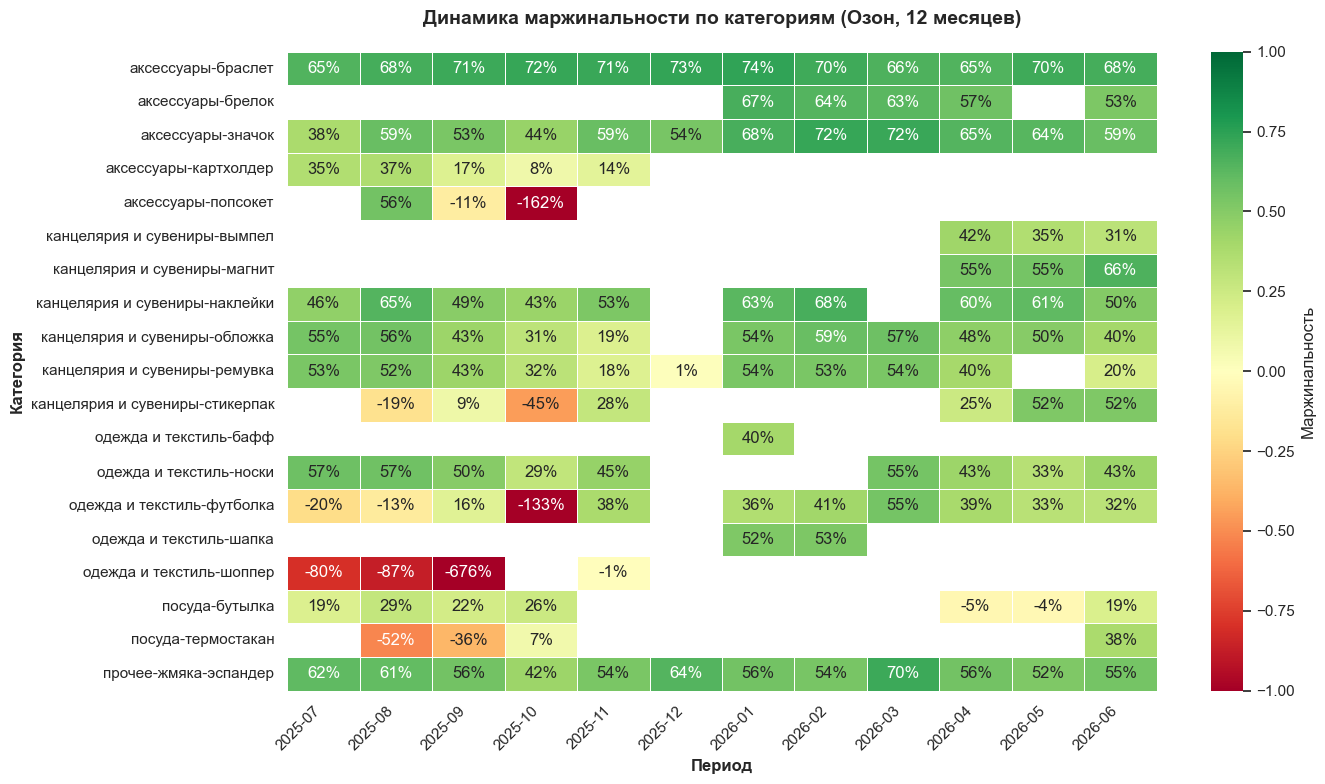

In [41]:
# Агрегируем данные по динамике маржинальности
ozon_ue_cat_monthly = ozon_sku_monthly.groupby(['supercategory','category', 'period'], as_index=False).agg(total_revenue=('total_revenue', 'sum'),
                                                                                                           profit=('profit', 'sum'))


ozon_ue_cat_monthly['marginality'] = calc_marginality(ozon_ue_cat_monthly['profit'], ozon_ue_cat_monthly['total_revenue'])
ozon_pivot_cat = pd.pivot_table(ozon_ue_cat_monthly, index=['supercategory', 'category'], columns='period', values='marginality')

# Строим heatmap 
plot_heatmap(ozon_pivot_cat,'Динамика маржинальности по категориям (Озон, 12 месяцев)')

- **Стабильные драйверы:** браслет (65–74%) и жмяка-эспандер (52–70%) демонстрируют устойчивую маржинальность на протяжении всего периода. Значок показывает рост с 38% в июле до 68–72% в начале 2026 года — позитивный тренд.

- **Критические просадки:** футболка уходила в глубокий минус в октябре (-133%) и июле (-20%), шоппер — системно убыточен (-80% ÷ -676%). Попсокет показал разовое падение до -162% в октябре. Это указывает на сезонные или акционные провалы, требующие отдельного анализа.

- **Восстановление после провалов:** стикерпак из отрицательных значений (-45% в октябре) вышел в плюс (25–52% к середине 2026). Наклейки и обложки стабильны, хотя обложка проседала до 19% в ноябре и 1% в декабре.

- **Сезонность:** летние месяцы (июль–август) — маржа выше, осенью (сентябрь–ноябрь) — просадки, зима–весна — восстановление. Особенно заметно на футболках, обложках, ремувках.

- **Зона риска:** бутылка (посуда) — маржа на грани (от -5% до 29%), требует контроля. Термостакан восстановился до 38% к июню, но история нестабильна.

#### Маркет

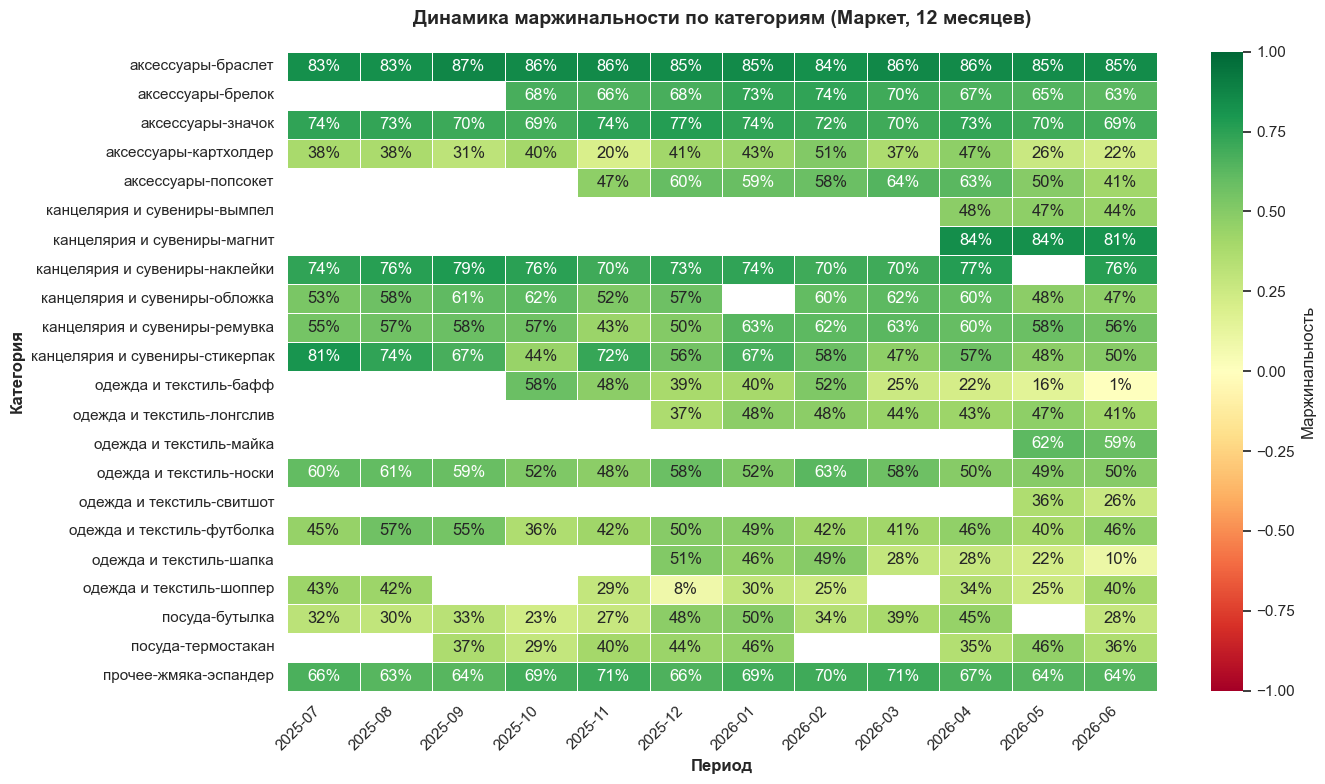

In [42]:
# Агрегируем данные по динамике маржинальности
market_ue_cat_monthly = market_sku_monthly.groupby(['supercategory','category', 'period'], as_index=False).agg(total_revenue=('total_revenue', 'sum'),
                                                                                                               profit=('profit', 'sum'))


market_ue_cat_monthly['marginality'] = calc_marginality(market_ue_cat_monthly['profit'], market_ue_cat_monthly['total_revenue'])
market_pivot_cat = pd.pivot_table(market_ue_cat_monthly, index=['supercategory', 'category'], columns='period', values='marginality')

# Строим heatmap 
plot_heatmap(market_pivot_cat,'Динамика маржинальности по категориям (Маркет, 12 месяцев)')

- **Стабильно высокие драйверы:** браслет (83–87%), значок (69–77%), жмяка-эспандер (63–71%), наклейки (70–79%). Эти категории сохраняют маржинальность на протяжении всех 12 месяцев без значимых просадок.

- **Плавное снижение:** бафф упал с 58% в октябре до 1% в июне — тренд требует внимания. Шапка аналогично: с 51% в декабре до 10% в июне. Вероятно, сезонный товар, который заканчивает цикл. Картхолдер — маржа снизилась с 38–51% в начале до 22–26% к середине года.

- **Восстановление:** стикерпак из 44% в октябре вернулся к 48–49% в мае–июне, хотя июнь немного просел. Бутылка восстановилась с 23% до 28–45%.

- **Зона риска:** свитшот (26–36%) — низкая маржа для одежды. Попсокет (41–64%) — нестабилен.

Маркет демонстрирует стабильно высокую маржинальность по большинству категорий. В отличие от Ozon, здесь нет убыточных позиций. Просадки связаны с сезонностью (бафф, шапка) или отдельными категориями, требующими контроля (свитшот, картхолдер). Это подтверждает, что Маркет — предпочтительная площадка для стабильной экономики.

## 8. Сегментация товаров

### Озон

In [43]:
# Агрегируем на уровне SKU за 12 месяцев
ozon_sku_summary = ozon_sku_monthly.groupby('sku_ozon', as_index=False).agg(category=('category', 'first'),
                                                                            supercategory=('supercategory', 'first'),
                                                                            cost_per_unit=('cost_per_unit', 'first'),
                                                                            ordered=('ordered', 'sum'),
                                                                            delivered=('delivered', 'sum'),
                                                                            returned=('returned', 'sum'),
                                                                            sold=('sold', 'sum'),
                                                                            total_revenue=('total_revenue', 'sum'),
                                                                            discount_points=('discount_points', 'sum'),
                                                                            cogs=('cogs', 'sum'),
                                                                            total_mp_fees=('total_mp_fees', 'sum'),
                                                                            profit=('profit', 'sum'),
                                                                            active_months=('period', 'nunique'))

# Вычисляем метрики для сегментации
ozon_sku_summary['marginality'] = calc_marginality(ozon_sku_summary['profit'], ozon_sku_summary['total_revenue'])
ozon_sku_summary['profit_share'] = ozon_sku_summary['profit'] / ozon_sku_summary['profit'].sum()
ozon_sku_summary['intensity'] = np.where(ozon_sku_summary['active_months'] > 0, ozon_sku_summary['sold'] / ozon_sku_summary['active_months'], 0)

display(ozon_sku_summary[['marginality', 'intensity', 'active_months']].describe())

,marginality,intensity,active_months
count,62.00,64.00,64.00
mean,0.26,2.71,6.50
std,0.72,2.20,3.18
min,-2.96,0.00,1.00
25%,0.23,1.00,4.00
50%,0.47,2.23,6.00
75%,0.60,3.85,10.00
max,0.75,11.00,12.00


**Обоснование порогов сегментации на основе фактического распределения**

Пороги сегментации выбраны на основе анализа эмпирического распределения метрик по всему ассортименту Ozon (см. раздел 3.4).

**Маржинальность (`margin_health`)**

Распределение маржинальности:
- Медиана: **48%**
- 25-й перцентиль: **27%**
- 75-й перцентиль: **61%**
- Минимум: -296%, Максимум: 75%

Выбранные пороги:
- **0%** — естественная граница между убыточными и прибыльными товарами
- **20%** — отсекает нижний квартиль (25-й перцентиль = 27%). Товары ниже этого порога формально прибыльны, но не покрывают операционные риски (возвраты, хранение, участие в акциях)
- **50%** — попадает между медианой (48%) и 75-м перцентилем (61%). Выделяет верхнюю часть распределения — товары с высокой добавленной стоимостью, типичные для мерча НКО при льготных тарифах площадок

**Интенсивность продаж (`intensity_level`)**

Распределение интенсивности (шт./мес. активности):
- Медиана: **2.2**
- 25-й перцентиль: **1.0**
- 75-й перцентиль: **3.9**
- Максимум: 11

Порог **3 шт./мес.** выбран между медианой и 75-м перцентилем. Он отграничивает верхний квартиль — товары, которые стабильно сходят со склада чаще большинства.

**Стабильность присутствия в заказах (`sales_presence`)**

Распределение количества активных месяцев (из 12):
- Медиана: **6**
- 25-й перцентиль: **4**
- 75-й перцентиль: **10**
- Минимум: 1, Максимум: 12

Пороги:
- **2 месяца** — ниже 25-го перцентиля (4). Отсекает эпизодические всплески, статистически неотличимые от случайных и короткие периоды продажи товара
- **7 месяцев** — между медианой (6) и 75-м перцентилем (10). Товары, активные 8+ месяцев, демонстрируют устойчивые продажи

In [44]:
# Задаем пороги для сегментации

# Маржинальность: <0%, 0-20%, 20-50%, >50%
MARGIN_BINS = [-np.inf, -0.0001, 0.20, 0.50, np.inf]
MARGIN_LABELS = ['Отрицательная маржа', 'Низкая маржа (0-20%)', 
                 'Средняя маржа (20-50%)', 'Высокая маржа (>50%)']

# Интенсивность: ≥3 шт./мес. = высокая частота
INTENSITY_THRESHOLD = 3

# Представленность на витрине: 1-2 мес., 3-7 мес., 8-12 мес.
SALES_PRESENCE_BINS = [0, 2, 7, 12]
SALES_PRESENCE_LABELS = ['Точечное присутствие', 'Периодическое присутствие', 'Стабильное присутствие']

In [45]:
# Определяем сегменты
ozon_sku_summary = segment_sku(ozon_sku_summary,
                               margin_col='marginality',
                               intensity_col='intensity', 
                               months_col='active_months',
                               margin_bins=MARGIN_BINS,
                               margin_labels=MARGIN_LABELS,
                               intensity_threshold=INTENSITY_THRESHOLD,
                               sales_presence_bins=SALES_PRESENCE_BINS,
                               sales_presence_labels=SALES_PRESENCE_LABELS)

# Выводим данные
print(f"Всего SKU в витрине Ozon: {len(ozon_sku_summary)}")

display(ozon_sku_summary[['sku_ozon', 'category', 'supercategory', 'sold', 'total_revenue', 
                           'total_mp_fees', 'profit', 'marginality', 'final_segment']].head(3))

Всего SKU в витрине Ozon: 64


,sku_ozon,category,supercategory,sold,total_revenue,total_mp_fees,profit,marginality,final_segment
0,Бафф_красный,бафф,одежда и текстиль,3,3192.00,267.49,1274.51,0.40,Средняя маржа (20-50%) + Низкая частота + Точе...
1,Брелок_металлический_голубой,брелок,аксессуары,4,2609.00,419.45,1429.55,0.55,Высокая маржа (>50%) + Низкая частота + Период...
2,Брелок_металлический_красный,брелок,аксессуары,29,19994.00,2035.54,12448.46,0.62,Высокая маржа (>50%) + Высокая частота + Перио...


In [46]:
ozon_sku_summary.query('sku_ozon == "ф_донор_S"')

,sku_ozon,category,supercategory,cost_per_unit,ordered,delivered,returned,sold,total_revenue,discount_points,cogs,total_mp_fees,profit,active_months,marginality,profit_share,intensity,margin_health,intensity_level,sales_presence,final_segment
60,ф_донор_S,футболка,одежда и текстиль,770,0,0,0,0,0.00,0.00,0,0.00,0.00,1,<NA>,0.00,0.00,NaN,Без продаж,Точечное присутствие,Без продаж


In [47]:
# Оцениваем распределение SKU по маржинальности
summary_ozon = ozon_sku_summary.groupby('margin_health', as_index=False).agg({'sku_ozon': 'count',
                                                                              'sold': 'sum',
                                                                              'profit_share': 'sum'})

with pd.option_context('display.max_colwidth', None):
    display(summary_ozon.sort_values(by='profit_share'))

,margin_health,sku_ozon,sold,profit_share
0,Отрицательная маржа,8,210,-0.19
1,Низкая маржа (0-20%),6,68,0.04
2,Средняя маржа (20-50%),21,307,0.32
3,Высокая маржа (>50%),27,507,0.82


Высокая маржа (>50%) — 27 SKU (43.5% ассортимента) генерируют 82% всей прибыли. Это ядро ассортимента: браслеты, значки, брелоки, жмяка-эспандер. Именно эти товары должны быть в фокусе масштабирования.

Средняя маржа (20–50%) — 21 SKU (33.9%) дают 32% прибыли. Вторая по значимости группа после ядра. Потенциал для перехода в высокомаржинальный сегмент через точечное повышение цены (10–15%) на SKU с наибольшей интенсивностью продаж. Остальные — держать под контролем, не выводить.

Низкая маржа (0–20%) — 6 SKU (9.7%) дают 4% прибыли. Пограничная зона: формально прибыльны, но не покрывают операционные риски. Требуют пересмотра цены или себестоимости.

Отрицательная маржа — 8 SKU (12.9%) съедают 19% прибыли. Это шоппер, футболка (частично), термостакан, стикерпак, попсокет. К выводу: эти SKU требуют срочного аудита — либо повышение цены, либо вывод из ассортимента на Ozon.

In [48]:
# Сводка по комбинированным сегментам
ozon_segment_summary = ozon_sku_summary.groupby('final_segment').agg(sku_count=('sku_ozon', 'count'),
                                                                     sku_list=('sku_ozon', lambda x:  ', '.join(x.astype(str))))

with pd.option_context('display.max_colwidth', None):
    display(ozon_segment_summary)

,sku_count,sku_list
final_segment,,
Без продаж,2,"сб_(4-)_белый, ф_донор_S"
Высокая маржа (>50%) + Высокая частота + Периодическое присутствие,3,"Брелок_металлический_красный, магнит, носки_донор_ж"
Высокая маржа (>50%) + Высокая частота + Стабильное присутствие,5,"жмяка_сердце_жест, жмяка_сердце_мягкий, сб_(1+)_красный, сб_(2+)_красный, сб_(3+)_красный"
Высокая маржа (>50%) + Низкая частота + Периодическое присутствие,9,"Брелок_металлический_голубой, Брелок_металлический_розовый, сб_(1+)_белый, сб_(1-)_белый, сб_(2+)_белый, сб_(2-)_белый, сб_(3+)_белый, сб_(3-)_белый, сб_(4+)_белый"
Высокая маржа (>50%) + Низкая частота + Стабильное присутствие,9,"авто_красный, значок_50, значок_друзья, набор_значков_друзья, сб_(1-)_красный, сб_(2-)_красный, сб_(3-)_красный, сб_(4+)_красный, сб_(4-)_красный"
Высокая маржа (>50%) + Низкая частота + Точечное присутствие,1,шапка
Низкая маржа (0-20%) + Низкая частота + Периодическое присутствие,6,"бутылка_650, картхолдер_магнит_к, картхолдер_магнит_ч, термо_нене, термо_сдавал, ф_донор_XL"
Отрицательная маржа + Высокая частота + Периодическое присутствие,6,"попсокет, стикерпак_белый, стикерпак_голубой, стикерпак_желтый, ф_донор_M, шоппер_красный"
Отрицательная маржа + Низкая частота + Периодическое присутствие,1,термо_ДС


In [49]:
# Добавляем рекомендации по ассортименту
ozon_sku_recommendations = add_recommendations(ozon_sku_summary, sku_col='sku_ozon', segment_col='final_segment')

print(f"Ozon: {len(ozon_sku_recommendations)} SKU")
with pd.option_context('display.max_colwidth', None):
    display(ozon_sku_recommendations[['sku_ozon', 'final_segment', 'sold', 'profit', 'marginality', 'recommendation']].head(10))

Ozon: 64 SKU


,sku_ozon,final_segment,sold,profit,marginality,recommendation
0,Бафф_красный,Средняя маржа (20-50%) + Низкая частота + Точечное присутствие,3,1274.51,0.40,Ассортимент (1–2 шт.)
1,Брелок_металлический_голубой,Высокая маржа (>50%) + Низкая частота + Периодическое присутствие,4,1429.55,0.55,Ассортимент (1–2 шт.)
2,Брелок_металлический_красный,Высокая маржа (>50%) + Высокая частота + Периодическое присутствие,29,12448.46,0.62,Ядро (держать в наличии)
3,Брелок_металлический_розовый,Высокая маржа (>50%) + Низкая частота + Периодическое присутствие,5,1993.47,0.61,Ассортимент (1–2 шт.)
4,Вымпел,Средняя маржа (20-50%) + Высокая частота + Периодическое присутствие,22,6386.71,0.35,Повысить цену (тест)
5,авто_красный,Высокая маржа (>50%) + Низкая частота + Стабильное присутствие,33,6887.64,0.55,Ассортимент (1–2 шт.)
6,бутылка_650,Низкая маржа (0-20%) + Низкая частота + Периодическое присутствие,19,2520.78,0.15,Ассортимент (1–2 шт.)
7,жмяка_банан,Средняя маржа (20-50%) + Высокая частота + Стабильное присутствие,32,12132.97,0.48,Повысить цену (тест)
8,жмяка_сердце_жест,Высокая маржа (>50%) + Высокая частота + Стабильное присутствие,52,21377.12,0.59,Ядро (держать в наличии)
9,жмяка_сердце_мягкий,Высокая маржа (>50%) + Высокая частота + Стабильное присутствие,55,24128.42,0.60,Ядро (держать в наличии)


На основании сегментов были сформулированы рекомендации для каждого SKU.

| Название | Смысл |
|----------|-------|
| **Ядро (держать в наличии)** | Пополнять по факту продаж, не допускать out-of-stock |
| **Повысить цену (тест)** | Поднять на 10–15%, следить за продажами |
| **Контроль остатков / Вывод вариаций** | Следить за операционными расходами, вывозить товары с длительным сроком хранения, исключать товар из ассортимента |
| **Ассортимент (1–2 шт.)** | Держать минимум, не завозить больше |
|**Аудит карточки**| Товар не нашёл спроса, но потенциально может быть прибыльным|

In [50]:
# Выводим распределение SKU по рекомендациям
display(ozon_sku_recommendations.groupby('recommendation', as_index=False)['sku_ozon'].nunique())

,recommendation,sku_ozon
0,Ассортимент (1–2 шт.),38
1,Аудит карточки,2
2,Контроль остатков / Вывод вариаций,8
3,Повысить цену (тест),8
4,Ядро (держать в наличии),8


- **Ядро (держать в наличии)** — 8 SKU (12,5% ассортимента). Основные драйверы прибыли: браслеты (красные), жмяка, авто-наклейки, носки_донор_ж. Требуют постоянного контроля остатков.
- **Повысить цену (тест)** — 8 SKU (12,5%). Товары с хорошим оборотом, но низкой или средней маржой. Потенциал для повышения цены на 10–15%.
- **Контроль остатков / Вывод вариаций** — 8 SKU (12,5%). Убыточные позиции: шоппер, попсокет, убыточные футболки, часть стикерпаков. Не выводить категорию целиком, но убрать с Ozon медленно оборачивающиеся размеры/цвета (перенести на Маркет), чтобы избежать повторения сценария Q4 2025.
- **Аудит карточки** — 2 SKU (3%). Товары без продаж. Требуют проверки видимости в поиске, наличия остатков на складе и корректности карточки.
- **Ассортимент (1–2 шт.)** — 38 SKU (59,4%). "Длинный хвост": белые браслеты, значки (кроме топовых), картхолдеры, шапка, бафф. Держать минимальный остаток, не масштабировать.

**Итого:** 10 SKU требуют внимания по наличию (8 — ядро + 2 — аудит), 16 SKU — по цене (из них 8 — критическая зона). Остальные 38 SKU — поддерживающий ассортимент.

In [51]:
# Экспорт в Excel
ozon_sku_recommendations.merge(master_df[['sku_ozon', 'sku']], on='sku_ozon', how='left').to_excel('озон_рекомендации_SKU.xlsx')

### Маркет

In [52]:
# Агрегируем на уровне SKU за 12 месяцев
market_sku_summary = market_sku_monthly.groupby('sku_market', as_index=False).agg(category=('category', 'first'),
                                                                            supercategory=('supercategory', 'first'),
                                                                            cost_per_unit=('cost_per_unit', 'first'),
                                                                            sold=('sold', 'sum'),
                                                                            total_revenue=('total_revenue', 'sum'),
                                                                            cogs=('cogs', 'sum'),
                                                                            total_mp_fees=('total_mp_fees', 'sum'),
                                                                            profit=('profit', 'sum'),
                                                                            active_months=('period', 'nunique'))

# Вычисляем метрики для сегментации
market_sku_summary['marginality'] = calc_marginality(market_sku_summary['profit'], market_sku_summary['total_revenue'])
market_sku_summary['profit_share'] = market_sku_summary['profit'] / market_sku_summary['profit'].sum()
market_sku_summary['intensity'] = np.where(market_sku_summary['active_months'] > 0, market_sku_summary['sold'] / market_sku_summary['active_months'], 0)

display(market_sku_summary[['marginality', 'intensity', 'active_months']].describe())

,marginality,intensity,active_months
count,101.00,103.00,103.00
mean,0.54,3.17,5.60
std,0.18,3.48,3.02
min,0.20,0.00,1.00
25%,0.39,1.50,3.00
50%,0.54,2.00,5.00
75%,0.68,3.10,8.00
max,0.87,27.00,12.00


In [53]:
# Определяем сегменты
market_sku_summary = segment_sku(market_sku_summary,
                                 margin_col='marginality',
                                 intensity_col='intensity',
                                 months_col='active_months',
                                 margin_bins=MARGIN_BINS,
                                 margin_labels=MARGIN_LABELS,
                                 intensity_threshold=INTENSITY_THRESHOLD,
                                 sales_presence_bins=SALES_PRESENCE_BINS,
                                 sales_presence_labels=SALES_PRESENCE_LABELS)
# Выводим данные
print(f"Всего SKU в витрине Маркет: {len(market_sku_summary)}")

display(market_sku_summary[['sku_market', 'category', 'supercategory', 'sold', 'total_revenue', 
                           'total_mp_fees', 'profit', 'marginality', 'final_segment']].head(3))

Всего SKU в витрине Маркет: 103


,sku_market,category,supercategory,sold,total_revenue,total_mp_fees,profit,marginality,final_segment
0,heart_black_lxl,футболка,одежда и текстиль,8,14331.00,753.32,4777.68,0.33,Средняя маржа (20-50%) + Низкая частота + Пери...
1,heart_black_sm,футболка,одежда и текстиль,4,6787.00,284.04,2102.96,0.31,Средняя маржа (20-50%) + Низкая частота + Пери...
2,heart_red_lxl,футболка,одежда и текстиль,6,10692.00,684.24,3407.76,0.32,Средняя маржа (20-50%) + Низкая частота + Пери...


In [54]:
# Оцениваем распределение SKU по сегментам
summary_market = market_sku_summary.groupby('margin_health', as_index=False).agg({'sku_market': 'count',
                                                                              'sold': 'sum',
                                                                              'profit_share': 'sum'})

with pd.option_context('display.max_colwidth', None):
    display(summary_market.sort_values(by='profit_share'))

,margin_health,sku_market,sold,profit_share
0,Средняя маржа (20-50%),45,557,0.28
1,Высокая маржа (>50%),56,1344,0.72


**Высокая маржа (>50%)** — 56 SKU (55.4% ассортимента) генерируют **72% всей прибыли**. Это основная масса ассортимента Маркета: браслеты, значки, брелоки, наклейки, жмяка-эспандер. Большинство товаров на Маркете стабильно прибыльны.

**Средняя маржа (20–50%)** — 45 SKU (44.6% ассортимента) дают **28% прибыли**. Все категории на Маркете прибыльны — убыточных SKU нет. Это подтверждает, что Маркет — предпочтительная площадка для размещения товаров.

**Отсутствие низкой и отрицательной маржи** на Маркете объясняется субсидированием логистики и хранения площадкой. Это делает Маркет безопасной площадкой для тестирования новых товаров и размещения "длинного хвоста" ассортимента.

In [55]:
# Сводка по комбинированным сегментам
market_segment_summary = market_sku_summary.groupby('final_segment').agg(sku_count=('sku_market', 'count'),
                                                                     sku_list=('sku_market', lambda x:  ', '.join(x.astype(str))))
                                                                         
with pd.option_context('display.max_colwidth', None):
    display(market_segment_summary)

,sku_count,sku_list
final_segment,,
Без продаж,2,"майка_XXS, майка_XXXL"
Высокая маржа (>50%) + Высокая частота + Периодическое присутствие,10,"авто_красный, магнит, носки_донор_ж, носки_донор_м, носки_кровь_ж, носки_кровь_м, носки_спорт_ж, носки_спорт_м, обложка_толстая_красная_ачивки, стикерпак_3д_2_стикера"
Высокая маржа (>50%) + Высокая частота + Стабильное присутствие,9,"Брелок_металлический_красный, Попсокет, жмяка_сердце_жест, жмяка_сердце_мяг, значок_50, обложка_красная, ремувка, сб_(1+)_красный, сб_(3+)_красный"
Высокая маржа (>50%) + Высокая частота + Точечное присутствие,1,обложка_тонкая_голубая_ачивки
Высокая маржа (>50%) + Низкая частота + Периодическое присутствие,18,"Брелок_металлический_голубой, значок_друзья_голубой, значок_друзья_набор, значок_друзья_розовый, ремувка_вышивка, сб_(1+)_белый, сб_(1-)_белый, сб_(2+)_белый, сб_(3+)_белый, сб_(3-)_красный, сб_(4+)_красный, сб_(4-)_красный, стикерпак_голубой, стикерпак_желтый, ф_бег_XS, ф_бег_XXL, ф_бег_XXS, ф_бег_XXXL"
Высокая маржа (>50%) + Низкая частота + Стабильное присутствие,13,"Брелок_металлический_розовый, авто_желтый, жмяка_банан, значок_друзья, ремувка_kiss, сб_(1-)_красный, сб_(2+)_красный, сб_(2-)_красный, стикерпак_белый, ф_бег_L, ф_бег_M, ф_бег_S, ф_бег_XL"
Высокая маржа (>50%) + Низкая частота + Точечное присутствие,5,"майка_L, майка_S, обложка_тонкая_розовая_ачивки, попсокет_3д, сб_(3-)_белый"
Средняя маржа (20-50%) + Высокая частота + Периодическое присутствие,4,"Бафф_красный, Шапка, вымпел, картхолдер"
Средняя маржа (20-50%) + Высокая частота + Стабильное присутствие,1,бутылка_650


In [56]:
# Добавляем рекомендации по ассортименту
market_sku_recommendations = add_recommendations(market_sku_summary, sku_col='sku_market', segment_col='final_segment')

print(f"Маркет: {len(market_sku_recommendations)} SKU")
with pd.option_context('display.max_colwidth', None):
    display(market_sku_recommendations[['sku_market', 'final_segment', 'sold', 'profit', 'marginality', 'recommendation']].head(10))

Маркет: 103 SKU


,sku_market,final_segment,sold,profit,marginality,recommendation
0,heart_black_lxl,Средняя маржа (20-50%) + Низкая частота + Периодическое присутствие,8,4777.68,0.33,Ассортимент (1–2 шт.)
1,heart_black_sm,Средняя маржа (20-50%) + Низкая частота + Периодическое присутствие,4,2102.96,0.31,Ассортимент (1–2 шт.)
2,heart_red_lxl,Средняя маржа (20-50%) + Низкая частота + Периодическое присутствие,6,3407.76,0.32,Ассортимент (1–2 шт.)
3,heart_red_sm,Средняя маржа (20-50%) + Низкая частота + Периодическое присутствие,8,5150.73,0.35,Ассортимент (1–2 шт.)
4,smile_black_lxl,Средняя маржа (20-50%) + Низкая частота + Периодическое присутствие,7,4197.15,0.34,Ассортимент (1–2 шт.)
5,smile_black_sm,Средняя маржа (20-50%) + Низкая частота + Периодическое присутствие,4,3001.37,0.38,Ассортимент (1–2 шт.)
6,smile_red_lxl,Средняя маржа (20-50%) + Низкая частота + Периодическое присутствие,9,5625.70,0.34,Ассортимент (1–2 шт.)
7,smile_red_sm,Средняя маржа (20-50%) + Низкая частота + Периодическое присутствие,9,3417.20,0.25,Ассортимент (1–2 шт.)
8,Бафф_красный,Средняя маржа (20-50%) + Высокая частота + Периодическое присутствие,35,17161.21,0.43,Повысить цену (тест)
9,Бафф_красный_флисовый,Средняя маржа (20-50%) + Низкая частота + Периодическое присутствие,20,5443.29,0.32,Ассортимент (1–2 шт.)


In [57]:
# Выводим распределение SKU по рекомендациям
display(market_sku_recommendations.groupby('recommendation', as_index=False)['sku_market'].nunique())

,recommendation,sku_market
0,Ассортимент (1–2 шт.),75
1,Аудит карточки,2
2,Повысить цену (тест),6
3,Ядро (держать в наличии),20


- **Ядро (держать в наличии)** — 20 SKU (19% ассортимента). Основные драйверы: браслеты, значки, брелоки, жмяка-эспандер. Требуют постоянного контроля остатков и приоритетного пополнения.

- **Повысить цену (тест)** — 9 SKU (9%). Середняки с потенциалом роста маржи: картхолдеры, свитшот, отдельные позиции в одежде. Целевой диапазон повышения — 10–15% с мониторингом продаж.

- **Ассортимент (1–2 шт.)** — 74 SKU (72%). "Длинный хвост": низкооборотные товары, белые версии, редкие размеры, часть одежды. Держать минимальный остаток для полноты ассортимента, не масштабировать.

**Итого:** 20 SKU — ядро, требующее фокуса; 9 SKU — потенциал повышения цены; 74 SKU — поддерживающий ассортимент. Убыточных позиций на Маркете нет.

In [58]:
# Экспорт в Excel
market_sku_recommendations.merge(master_df[['sku_market', 'sku']], on='sku_market', how='left').to_excel('маркет_рекомендации_SKU.xlsx')

## 9. Анализ ценообразования

**Вводное ограничение**

Анализ ценообразования проведен только для товаров с высоким и стабильным спросом (`intensity_level == "Высокая"` и `sales_presence == "Стабильное присутствие"`). Это обусловлено методологическим ограничением: для товаров с низкой интенсивностью продаж (1–5 единиц в месяц) статистическая выборка недостаточна для корректной оценки влияния цены на объем продаж. Любые колебания объема в этой группе являются случайным шумом (сезонность, единичные заказы, изменение ранжирования), а не реакцией на изменение цены.

Товары с эпизодическим и точечным присутствием исключены из корреляционного анализа. Для них доступны только точечные наблюдения, не позволяющие построить зависимость "цена — объем". Выводы по ценообразованию, представленные ниже, релевантны исключительно для ядра ассортимента — товаров, формирующих основу выручки и прибыли бизнеса.

### Озон

In [59]:
# Определяем размер скидки на товары
ozon_sku_monthly['discount'] = (ozon_sku_monthly['discount_points'] / ozon_sku_monthly['total_revenue']).round(3)
display(ozon_sku_monthly['discount'].describe())

count   311.00
mean      0.06
std       0.07
min       0.00
25%       0.04
50%       0.05
75%       0.05
max       0.55
Name: discount, dtype: float64

In [60]:
# Анализируем скидки по сегментам
discount_ozon_df = ozon_sku_monthly.copy().merge(ozon_sku_summary[['sku_ozon', 'final_segment', 'intensity_level', 'sales_presence']],
                                                 on='sku_ozon', how='left')

discount_ozon = discount_ozon_df.groupby('sku_ozon', as_index=False).agg(min_discount=('discount', 'min'),
                                                                         median_discount=('discount', 'median'),
                                                                         max_discount=('discount', 'max'),
                                                                         min_base_price=('base_price', 'min'),
                                                                         max_base_price=('base_price', 'max'),
                                                                         sold=('sold', 'sum'),
                                                                         intensity_level=('intensity_level', 'first'),
                                                                         sales_presence=('sales_presence', 'first'),
                                                                         final_segment=('final_segment', 'first'))


discount_ozon['price_spread'] = (discount_ozon['max_base_price'] - discount_ozon['min_base_price']) / discount_ozon['min_base_price']

display(discount_ozon.groupby('final_segment', as_index=False).agg(median_price_spread=('price_spread', 'median'),
                                                                   min_discount=('min_discount', 'min'),
                                                                   median_discount=('median_discount', 'median'),
                                                                   max_discount=('max_discount', 'max')))

,final_segment,median_price_spread,min_discount,median_discount,max_discount
0,Без продаж,<NA>,NaN,NaN,NaN
1,Высокая маржа (>50%) + Высокая частота + Перио...,0.31,0.00,0.07,0.55
2,Высокая маржа (>50%) + Высокая частота + Стаби...,0.39,0.00,0.05,0.42
3,Высокая маржа (>50%) + Низкая частота + Период...,0.27,0.03,0.05,0.17
4,Высокая маржа (>50%) + Низкая частота + Стабил...,0.51,0.00,0.05,0.30
5,Высокая маржа (>50%) + Низкая частота + Точечн...,0.01,0.05,0.05,0.05
6,Низкая маржа (0-20%) + Низкая частота + Период...,0.30,0.00,0.10,0.41
7,Отрицательная маржа + Высокая частота + Период...,2.89,0.00,0.03,0.09
8,Отрицательная маржа + Низкая частота + Периоди...,6.17,0.00,0.00,0.00
9,Отрицательная маржа + Низкая частота + Стабиль...,5.66,0.00,0.05,0.09


1. **Ядро ассортимента продается без скидок.** Минимальная скидка во всех сегментах с высокой маржой равна 0% — товары регулярно продаются по полной цене. Медианная скидка составляет 5–7%, что подтверждает: спрос на эти товары органический и не требует ценового стимулирования.

2. **Убыточные сегменты — ценовой хаос.** Разброс базовых цен у товаров с отрицательной маржой достигает 289–617% (медианные значения). Это не управляемое ценообразование, а хаотичные попытки распродать остатки, которые не приводят к росту спроса. Минимальная скидка у этих товаров также равна 0%, то есть проблема не в "завышенной цене", а в себестоимости и/или затратах на хранение и логистику.

3. **Низкая маржа → более глубокие скидки.** В сегментах с низкой маржой медианная скидка выше (9–12%), чем в высокомаржинальных (5–7%). Это указывает на то, что товары с низкой рентабельностью чаще вовлекаются в промо-активности площадки.

4. **Скидки не управляются продавцом.** Данные показывают, что скидки применяются маркетплейсом по внутренним алгоритмам, а не являются инструментом ценовой стратегии продавца. В пределах одной категории одни SKU продаются со скидкой, другие — без, без видимой связи с объемом продаж или маржинальностью.

In [87]:
# Оценим корреляцию между ценой продажи, базовой ценой и количеством продаж
sku_lst = ozon_sku_summary.query('intensity_level == "Высокая" and sales_presence == "Стабильное присутствие"')['sku_ozon'].to_list()
corr_price = []
corr_sell = []

for sku in sku_lst:
    sku_data = ozon_sku_monthly.query('sku_ozon == @sku')
    # Корреляция base_price <-> selling_price
    corr_price.append(sku_data[['base_price', 'selling_price']].corr().iloc[0, 1])

     # Корреляция selling_price <-> sold
    corr_sell.append(sku_data[['selling_price', 'sold']].corr().iloc[0, 1])

sku_price_corr = pd.DataFrame({'sku_ozon': sku_lst, 'corr_price': corr_price, 'corr_sell': corr_sell})

display(sku_price_corr.sort_values(by='corr_price', ascending=False))

print(f"Среднее значение корреляции цены продажи и базовой цены топ товаров: {sku_price_corr['corr_price'].mean():.2f}")
print(f"Среднее значение корреляции продаж и цены продажи топ товаров: {sku_price_corr['corr_sell'].mean():.2f}")

,sku_ozon,corr_price,corr_sell
5,ремувка_kiss,1.00,-0.64
4,обложка_тонкая,0.98,-0.50
7,сб_(2+)_красный,0.98,-0.44
1,жмяка_сердце_жест,0.97,-0.25
0,жмяка_банан,0.94,0.10
6,сб_(1+)_красный,0.84,-0.60
3,обложка_красная,0.79,-0.54
2,жмяка_сердце_мягкий,0.79,-0.11
8,сб_(3+)_красный,0.48,-0.25


Среднее значение корреляции цены продажи и базовой цены топ товаров: 0.86
Среднее значение корреляции продаж и цены продажи топ товаров: -0.36


**Методологическое ограничение**<br>
Анализ проведен на основе месячной агрегации (12 точек наблюдения на SKU). Отсутствие идентификатора заказа (posting_number) в финансовых отчетах Озона не позволяет атрибутировать доходы и расходы на уровне отдельных транзакций. Высокие коэффициенты корреляции на малой выборке могут быть частично обусловлены эффектом сглаживания внутри месячных агрегатов, поэтому результаты следует интерпретировать как макро-тренды, а не точные оценки эластичности. 

**Средние значения по топ-10 SKU**
- Корреляция `base_price` ↔ `selling_price`: **0.86** — изменения базовой цены предсказуемо транслируются в цену транзакции
- Корреляция `selling_price` ↔ `sold`: **-0.36** — слабая отрицательная связь, объем слабо реагирует на изменение цены

**Индивидуальные паттерны**
- `жмяка_банан`: корреляция **+0.10** — классический признак неэластичного спроса, аудитория готова платить больше без потери объема
- `ремувка_kiss`: корреляция **-0.64** — единственный SKU с выраженной ценовой чувствительностью, но при этом `corr_price` = 1.00 (базовая цена полностью транслируется в цену продажи)

**Выводы**

1. **По имеющимся данным не оьнаружена выраженная линейная связь между изменением средней цены реализации и количеством продаж.** Средняя корреляция `selling_price` ↔ `sold` составляет -0.37, что указывает на слабую связь между ценой и объемом продаж. Из-за малого числа наблюдений и влияния других факторов этого недостаточно для оценки ценовой эластичности.

3. **Основные драйверы спроса — органический трафик, наличие товара на складе и событийный календарь.**

4. **Контроль над ценой на макро-уровне сохранен.** Корреляция 0.87 между базовой ценой и ценой реализации означает, что изменения цены в личном кабинете предсказуемо отражаются на средней цене транзакции в рамках месяца.

**Рекомендация**<br>
Экстремальный разброс цен (до 617%) и глубокая отрицательная маржинальность — следствие вынужденных распродаж складских остатков для остановки затрат на хранение. Управление ценой в этой ситуации — реактивный инструмент, а не стратегия. Требуется сместить фокус на управление товарными остатками и внедрить систему раннего оповещения для товаров, теряющих оборачиваемость.

### Маркет

In [62]:
# Определяем размер скидки на товары
df = market_delivered_df_12m.copy()
df['discount'] = (market_delivered_df_12m['discount_market'] / market_delivered_df_12m['base_price']).round(3)
df['discount'].describe()

count   1702.00
mean       0.15
std        0.14
min        0.00
25%        0.05
50%        0.09
75%        0.23
max        1.00
Name: discount, dtype: float64

In [63]:
# Анализируем скидки по сегментам
discount_market = df.groupby('sku_market', as_index=False).agg(min_discount=('discount', 'min'),
                                                               median_discount=('discount', 'median'),
                                                               max_discount=('discount', 'max'),
                                                               min_base_price=('base_price', 'min'),
                                                               max_base_price=('base_price', 'max'))

discount_market['price_spread'] = (discount_market['max_base_price'] - discount_market['min_base_price']) / discount_market['min_base_price']

discount_market = discount_market.merge(market_sku_summary[['sku_market', 'sold', 'active_months',
                                                            'margin_health', 'intensity_level',
                                                            'sales_presence', 'final_segment']], on='sku_market', how='outer')

discount_market.groupby('final_segment', as_index=False).agg(median_price_spread=('price_spread', 'median'),
                                                             min_discount=('min_discount', 'min'),
                                                             median_discount=('median_discount', 'median'),
                                                             max_discount=('max_discount', 'max'))

,final_segment,median_price_spread,min_discount,median_discount,max_discount
0,Без продаж,NaN,NaN,NaN,NaN
1,Высокая маржа (>50%) + Высокая частота + Перио...,0.60,0.00,0.18,0.63
2,Высокая маржа (>50%) + Высокая частота + Стаби...,0.49,0.00,0.08,1.00
3,Высокая маржа (>50%) + Высокая частота + Точеч...,0.09,0.14,0.14,0.15
4,Высокая маржа (>50%) + Низкая частота + Период...,0.40,0.00,0.09,0.63
5,Высокая маржа (>50%) + Низкая частота + Стабил...,0.48,0.00,0.08,0.58
6,Высокая маржа (>50%) + Низкая частота + Точечн...,0.11,0.00,0.11,0.33
7,Средняя маржа (20-50%) + Высокая частота + Пер...,0.57,0.00,0.08,0.58
8,Средняя маржа (20-50%) + Высокая частота + Ста...,0.33,0.00,0.10,0.58
9,Средняя маржа (20-50%) + Высокая частота + Точ...,0.16,0.00,0.20,0.34


1. **Ядро ассортимента — минимальные скидки.** В сегментах с высокой маржой и стабильными продажами минимальная скидка равна 0%, медианная — 8%. Товары регулярно продаются по полной цене, что подтверждает органический характер спроса.

2. **Разброс цен выше, чем на Ozon.** Медианный разброс базовых цен на Маркете составляет 33–74% против 27–47% на Ozon. Это объясняется большей вариативностью ассортимента (103 SKU против 64) и более активным участием площадки в ценообразовании.

3. **Скидки не управляются продавцом.** Как и на Ozon, скидки применяются маркетплейсом по внутренним алгоритмам. В пределах одной категории одни SKU продаются со скидкой, другие — без, без видимой связи с объемом продаж или маржинальностью.

4. **Максимальные скидки достигают 100%.** В сегменте высокой маржи со стабильными продажами зафиксированы скидки до 100% (продажа за 1 рубль). Это означает, что площадка полностью субсидирует отдельные промо-акции за свой счет, не влияя на доход продавца.

5. **Стабильность ≠ отсутствие скидок.** В отличие от Ozon, где ядро имело минимальную скидку 0%, на Маркете даже в стабильных сегментах медианная скидка составляет 8–10%. Это связано с тем, что Маркет активнее использует скидки как инструмент привлечения трафика, компенсируя их продавцу.

In [64]:
# Оценим корреляцию между ценой продажи, базовой ценой и количеством продаж
sku_lst = market_sku_summary.query('intensity_level == "Высокая" and sales_presence == "Стабильное присутствие"')['sku_market'].to_list()
corr_price = []
corr_sell = []

for sku in sku_lst:
    sku_data = market_sku.query('sku_market == @sku')
    # Корреляция base_price <-> selling_price
    corr_price.append(sku_data[['base_price', 'selling_price']].corr().iloc[0, 1])

     # Корреляция selling_price <-> sold
    corr_sell.append(sku_data[['selling_price', 'sold']].corr().iloc[0, 1])

sku_price_corr = pd.DataFrame({'sku_market': sku_lst, 'corr_price': corr_price, 'corr_sell': corr_sell})

display(sku_price_corr.sort_values(by='corr_price', ascending=False))

print(f"Среднее значение корреляции цены продажи и базовой цены топ товаров: {sku_price_corr['corr_price'].mean():.2f}")
print(f"Среднее значение корреляции продаж и цены продажи топ товаров: {sku_price_corr['corr_sell'].mean():.2f}")

,sku_market,corr_price,corr_sell
5,значок_50,0.54,-0.12
9,сб_(3+)_красный,0.47,0.23
7,ремувка,0.46,-0.38
8,сб_(1+)_красный,0.40,-0.06
3,жмяка_сердце_жест,0.36,0.01
0,Брелок_металлический_красный,0.34,-0.00
6,обложка_красная,0.32,-0.00
4,жмяка_сердце_мяг,0.24,-0.06
2,бутылка_650,0.02,-0.04
1,Попсокет,-0.06,-0.33


Среднее значение корреляции цены продажи и базовой цены топ товаров: 0.31
Среднее значение корреляции продаж и цены продажи топ товаров: -0.07


**Средние значения по топ-10 SKU**
- Корреляция `base_price` ↔ `selling_price`: **0.31** — слабая связь, алгоритмы скидок Маркета вносят значительный шум
- Корреляция `selling_price` ↔ `sold`: **-0.07** — эластичность отсутствует, объем не реагирует на цену

**Индивидуальные паттерны**
- `сб_(3+)_красный`: корреляция **+0.23** — рост цены сопровождается ростом продаж, что подтверждает неэластичность спроса для ключевых браслетов
- `ремувка`: корреляция **-0.38** — единственный SKU с выраженной ценовой чувствительностью
- `Попсокет`: корреляция **-0.33** — при отрицательной корреляции `base_price` ↔ `selling_price` (-0.06) это указывает на то, что цена продажи не связана с базовой ценой, а объем падает при росте скидок

**Выводы**

1. **Слабая связь между базовой и фактической ценой.** Корреляция 0.31 означает, что изменение базовой цены селлера незначительно влияет на изменение цены для покупателя. Алгоритмы скидок Маркета вносят существенный шум.

2. **На текущих данных нельзя корректно оценить ценовую эластичность.** В имеющихся данных не обнаружена выраженная линейная связь между изменением средней цены реализации и количеством продаж. Из-за малого числа наблюдений и влияния других факторов этого недостаточно для оценки ценовой эластичности.

3. **Органический спрос доминирует.** Товары с наибольшим объемом продаж (жмяка, значок_50, браслеты) продаются стабильно независимо от колебаний цен. Их выручка формируется за счет органического трафика, а не промо-активностей.

**Рекомендация**<br>
Для топ-SKU зафиксировать базовую цену на уровне, обеспечивающем целевую маржинальность.

## 10. Декомпозиция факторов влияния

### 10.1. Сезонность и событийный спрос

#### Озон

In [65]:
# Оценим месячную динамику спроса
ozon_seasonality = ozon_sku_monthly.groupby('period', as_index=False).agg(revenue=('revenue', 'sum'),
                                                                 profit=('profit', 'sum'),
                                                                 sold=('sold', 'sum'),
                                                                 active_sku=('sku_ozon', 'nunique'))

ozon_seasonality['avg_sold_per_sku'] = ozon_seasonality['sold'] / ozon_seasonality['active_sku']
ozon_seasonality['marginality'] = ozon_seasonality['profit'] / ozon_seasonality['revenue']

display(ozon_seasonality)   
display(ozon_seasonality.describe(include='number'))

,period,revenue,profit,sold,active_sku,avg_sold_per_sku,marginality
0,2025-07,41897.06,16972.76,67,41,1.63,0.41
1,2025-08,44893.44,16720.15,70,41,1.71,0.37
2,2025-09,109611.85,31258.64,215,41,5.24,0.29
3,2025-10,56646.34,-6169.80,229,37,6.19,-0.11
4,2025-11,48418.22,20171.55,104,27,3.85,0.42
5,2025-12,5604.70,3077.94,15,10,1.50,0.55
6,2026-01,31059.72,19679.20,44,30,1.47,0.63
7,2026-02,28738.30,18613.03,45,28,1.61,0.65
8,2026-03,22842.05,15371.23,44,33,1.33,0.67
9,2026-04,60961.62,33883.55,95,40,2.38,0.56


,revenue,profit,sold,active_sku,avg_sold_per_sku,marginality
count,12.00,12.00,12.00,12.00,12.00,12.00
mean,45032.52,17941.85,91.00,34.67,2.55,0.45
std,25723.71,11093.94,66.67,9.85,1.64,0.21
min,5604.70,-6169.80,15.00,10.00,1.33,-0.11
25%,30479.37,16382.92,44.75,29.50,1.49,0.40
50%,43395.25,18135.74,68.50,38.50,1.67,0.51
75%,55127.22,22145.03,102.50,41.00,2.74,0.58
max,109611.85,33883.55,229.00,45.00,6.19,0.67


**Ключевые наблюдения**

- **Событийные пики:** Максимальные объемы продаж зафиксированы в апреле (95 шт.) и июне (102 шт.) 2026 года, что коррелирует с Национальным днем донора (20 апреля) и Всемирным днем донора (14 июня).
- **Структурный кризис Q4 2025:** Сентябрь-октябрь 2025 г. характеризовались аномально высоким объемом продаж (до 229 шт. в октябре), который сопровождался отрицательной маржинальностью (-11%). Это указывает на паническую распродажу складских остатков, а не на органический рост спроса. Следствием стало истощение запасов к декабрю (всего 10 активных SKU и 15 проданных единиц), что привело к упущенной выручке в предновогодний период.
- **Восстановление маржинальности в 2026 году:** С января 2026 г. маржинальность стабилизировалась на уровне 50–67% при среднем объеме продаж 44–102 шт./мес. и 28–45 активных SKU. Это позволило максимизировать прибыль в событийные пики (апрель: 33.9 тыс. ₽ прибыли при марже 56%) без повторения октябрьского сценария "рост объема = убыток".

**Выводы**

1. Спрос жестко привязан к событийному календарю донорства, а не к календарной сезонности.
2. Кризис Q4 2025 — следствие ошибки управления остатками: паническая распродажа → дефицит в декабре.
3. Для реализации потенциала событийных пиков критически важно синхронизировать цикл поставок с ключевыми датами (апрель, июнь), обеспечивая наличие полного ассортимента за 3–4 недели до события.


#### Маркет

In [66]:
market_seasonality = market_sku_monthly.groupby('period', as_index=False).agg(total_revenue=('total_revenue', 'sum'),
                                                                 profit=('profit', 'sum'),
                                                                 sold=('sold', 'sum'),
                                                                 active_sku=('sku_market', 'nunique'))

market_seasonality['avg_sold_per_sku'] = market_seasonality['sold'] / market_seasonality['active_sku']
market_seasonality['marginality'] = market_seasonality['profit'] / market_seasonality['total_revenue']

display(market_seasonality)   
display(market_seasonality.describe(include='number'))

,period,total_revenue,profit,sold,active_sku,avg_sold_per_sku,marginality
0,2025-07,120769.00,64994.84,134,40,3.35,0.54
1,2025-08,59424.00,35922.16,70,28,2.50,0.60
2,2025-09,69892.00,39332.46,66,35,1.89,0.56
3,2025-10,58878.00,33747.27,80,31,2.58,0.57
4,2025-11,161644.00,86489.17,247,49,5.04,0.54
5,2025-12,169438.00,88918.43,191,59,3.24,0.52
6,2026-01,124890.00,67991.48,196,51,3.84,0.54
7,2026-02,59555.00,34325.70,74,37,2.00,0.58
8,2026-03,93668.00,48290.42,121,51,2.37,0.52
9,2026-04,180090.00,100890.18,270,70,3.86,0.56


,total_revenue,profit,sold,active_sku,avg_sold_per_sku,marginality
count,12.00,12.00,12.00,12.00,12.00,12.00
mean,119112.59,64290.29,158.42,48.08,3.14,0.55
std,51726.02,26669.64,82.13,14.11,0.98,0.03
min,58878.00,33747.27,66.00,28.00,1.89,0.50
25%,67307.75,38479.88,78.50,36.50,2.47,0.52
50%,122829.50,64106.13,143.50,50.00,2.96,0.54
75%,163592.50,87096.49,208.75,57.50,3.85,0.57
max,205640.00,107363.97,299.00,70.00,5.04,0.60


**Ключевые наблюдения**

- **Событийные пики:** Максимальные объемы продаж зафиксированы в апреле (270 шт.) и июне (299 шт.) 2026 года, что коррелирует с Национальным днем донора (20 апреля) и Всемирным днем донора (14 июня).
- **Календарный Q4:** Ноябрь (247 шт.) и декабрь (191 шт.) показали высокие объемы, что указывает на успешную капитализацию предновогоднего спроса.
- **Стабильность маржинальности:** При росте объема продаж в 3–4 раза относительно среднемесячного (158 шт.), маржинальность остается в узком коридоре 50–60% (среднее: 55%, стандартное отклонение: 3%). Это свидетельствует о здоровой юнит-экономике площадки и отсутствии разрушительных скидок в пиковые периоды.
- **Корреляция ассортимента и объема:** Расширение активного ассортимента до 60–70 SKU сопровождается ростом продаж до 200–300 шт., при этом средняя частота продаж на один SKU остается стабильной (2.0–4.3). Рост выручки обеспечивается вовлечением в продажи большего числа разных наименований, а не резким увеличением спроса на отдельные товары.

**Выводы**

1. Спрос имеет гибридный характер, сочетающий событийные пики (дни донора) и календарную сезонность (Q4).
2. Стабильно высокая маржинальность в пиковые месяцы указывает на корректный учет логистических издержек и отсутствие вынужденных распродаж.
3. Для реализации потенциала сезонных пиков критически важно расширять ассортимент в предшествующие периоды (за 3–4 недели до событий), так как объем продаж напрямую связан с количеством активных SKU.

### 10.2. Рекламная активность

#### Озон

| Название услуги в отчете Ozon | Код переменной | Фактор влияния (из ТЗ) | Механизм влияния на финансовый результат |
| :--- | :--- | :--- | :--- |
| Оплата за клик | `cpc_ads` | Рекламная активность | Performance-маркетинг. Прямая оплата за трафик. Влияет на охват. |
| Звёздные товары | `star_products` | Рекламная активность | Платное повышение видимости в поиске и категориях. Влияет на CTR. |
| Платный бренд | `paid_brand` | Рекламная активность | Брендированное размещение. Влияет на узнаваемость и конверсию. |
| Отзывы (Подписка Управление отзывами) | `review_fees` | Рекламная активность (инструмент конверсии) | Фиксированная плата. Влияет на социальное доказательство и CR карточки. |
| Баллы за скидки | `discount_points` | Скидка / Участие в акциях МП | Ценовой инструмент. Прямое снижение выручки. Не является драйвером объема (согласно п. 3.3). |

In [67]:
# Подсчет статистики по маркетинговым услугам
services = ['cpc_ads', 'star_products', 'paid_brand', 'review_fees']
total_sku = ozon_sku_monthly['sku_ozon'].nunique()
total_revenue = ozon_sku_monthly['total_revenue'].sum()

df_summary = pd.DataFrame({'service': services,
                           'active_periods': [ozon_sku_monthly.query(f'{s} != 0')['period'].nunique() for s in services],
                           'cnt_sku': [ozon_sku_monthly.query(f'{s} != 0')['sku_ozon'].nunique() for s in services],
                           'pct_of_sku': [ozon_sku_monthly.query(f'{s} != 0')['sku_ozon'].nunique() / total_sku * 100 for s in services] ,
                           'total_spend': [abs(ozon_sku_monthly[s].sum()) for s in services],
                           'pct_of_revenue': [abs(ozon_sku_monthly[s].sum()) / total_revenue * 100 for s in services]})


display(df_summary)

,service,active_periods,cnt_sku,pct_of_sku,total_spend,pct_of_revenue
0,cpc_ads,0,0,0.00,0.00,0.00
1,star_products,10,60,93.75,3099.23,0.54
2,paid_brand,2,25,39.06,297.08,0.05
3,review_fees,1,14,21.88,121.79,0.02


Маркетинговые кампании на площадке не подключены, текущий трафик и объем продаж формируются преимущественно органически.
Оценить влияние дополнительных механик площадки («Звёздные товары», «Платный бренд», «Управление отзывами») на финансовый результат невозможно из-за отсутствия данных по атрибуции заказов к конкретным кампаниям. Для полноценного анализа эффективности рекламных расходов требуется подключение сквозной аналитики и целевое выделение бюджетов на тестовые кампании.

#### Маркет

In [68]:
# Подсчет статистики по маркетинговым услугам
services = ['listing_placement', 'loyalty_program', 'boost_sales']
total_orders =  market_margin_df_12m['order_id'].nunique()
total_revenue = market_margin_df_12m['order_price'].sum()
market_margin_df_12m['period'] = market_margin_df_12m['date_ordered'].dt.to_period('M')

df_summary = pd.DataFrame({'service': services,
                           'active_periods': [market_margin_df_12m.query(f'{s} != 0')['period'].nunique() for s in services],
                           'cnt_orders': [market_margin_df_12m.query(f'{s} != 0')['order_id'].nunique() for s in services],
                           'pct_orders': [market_margin_df_12m.query(f'{s} != 0')['order_id'].nunique() / total_orders * 100 for s in services],
                           'total_spend': [abs(market_margin_df_12m[s].sum()) for s in services],
                           'pct_of_revenue': [abs(market_margin_df_12m[s].sum()) / total_revenue * 100 for s in services]})


display(df_summary)

,service,active_periods,cnt_orders,pct_orders,total_spend,pct_of_revenue
0,listing_placement,12,1535,87.17,139.94,0.01
1,loyalty_program,11,87,4.94,3385.00,0.21
2,boost_sales,12,501,28.45,9737.79,0.60


Системные маркетинговые кампании на площадке не ведутся, текущий трафик и объем продаж формируются преимущественно органически.
Оценить влияние дополнительных механик площадки (boost_sales, loyalty_program, listing_placement) на финансовый результат невозможно из-за отсутствия данных по атрибуции заказов к конкретным sku и маркетинговым активностям. Несмотря на формальное применение к части заказов (например, boost_sales затронул 28,45% заказов, а listing_placement — 87,17%), совокупные затраты на все сервисы продвижения составляют менее 1% от оборота. Системная стратегия продвижения отсутствует, поэтому вклад данных расходов в рост объема продаж статистически неразличим.

### 10.3. Выводы по декомпозиции

- Основной драйвер спроса — событийный календарь. Пики продаж приходятся на апрель и июнь (дни донора) на обеих площадках. На Маркете дополнительным фактором выступает предновогодний сезон (Q4).

- Ценовые аномалии — следствие ошибок управления складом. Кризис Q4 2025 на Ozon (распродажа ниже себестоимости, затем дефицит) — прямой результат отсутствия системы раннего оповещения по залежавшимся остаткам.

- Реклама не является драйвером продаж. Затраты на всех инструментах продвижения составляют < 1% от выручки на обеих площадках. Трафик и продажи формируются органически.

- Ключевой управляемый фактор — ассортимент и остатки. На обеих площадках объем продаж коррелирует с количеством активных SKU. Управление товарной матрицей и своевременное пополнение остатков перед событийными пиками — основной рычаг влияния на выручку.

## 11. Поиск утечек прибыли

### Озон

In [69]:
# Оцениваем затраты на сервисы Озон
ozon_fees_list = ['commission_ozon', 'logistics', 'last_mile', 'storage_cost',
                 'return_handling', 'reverse_logistics', 'cpc_ads',
                 'star_products', 'paid_brand', 'review_fees']

ozon_fees = ozon_sku_monthly[ozon_fees_list].sum().reset_index().sort_values(by=0, ascending=False)
ozon_fees.columns = ['fee', 'total']
ozon_fees['pct_fees'] = (ozon_fees['total'] / ozon_fees['total'].sum() * 100).round(2)

print(f"Всего сборов за 12 месяцев: {ozon_fees['total'].sum():,.2f} руб.")
display(ozon_fees)

Всего сборов за 12 месяцев: 107,582.58 руб.


,fee,total,pct_fees
1,logistics,54662.66,50.81
3,storage_cost,33540.82,31.18
0,commission_ozon,8023.75,7.46
2,last_mile,4419.72,4.11
7,star_products,3099.23,2.88
5,reverse_logistics,2922.53,2.72
4,return_handling,495.00,0.46
8,paid_brand,297.08,0.28
9,review_fees,121.79,0.11
6,cpc_ads,0.00,0.00


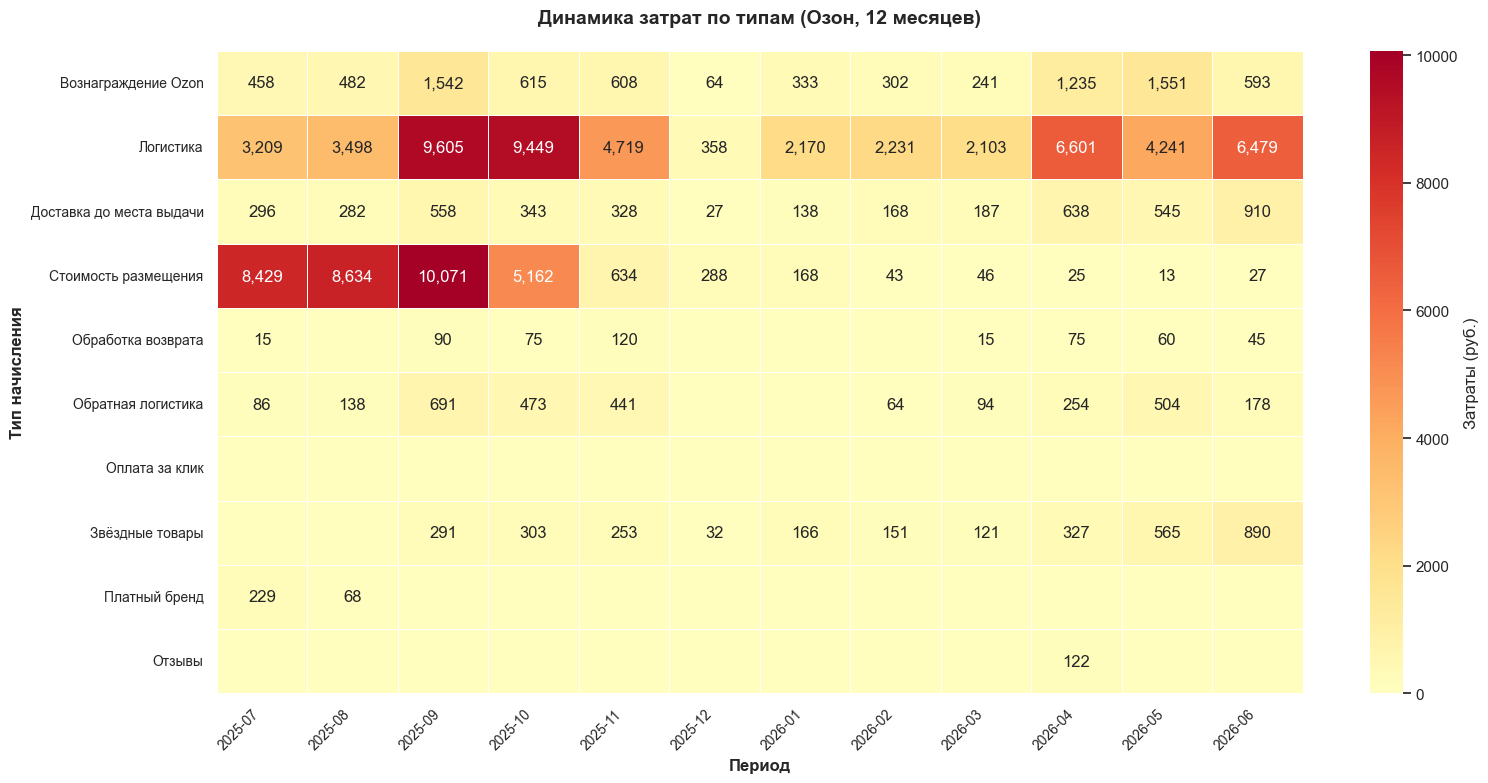

In [70]:
# Визуализируем динамику затрат
ozon_fees_period = ozon_sku_monthly.groupby('period')[ozon_fees_list].sum().T

rename_map = {v: k for k, v in ozon_ecom_cols.items()}
ozon_fees_period = ozon_fees_period.rename(index=rename_map)

heatmap_fees(ozon_fees_period, 'Динамика затрат по типам (Озон, 12 месяцев)')

**Суммарные сборы за 12 месяцев: 107 582,58 ₽**

| Статья | Сумма, ₽ | Доля, % |
|:---|:---|:---|
| Логистика | 54 662,66 | 50.81% |
| Хранение | 33 540,82 | 31.18% |
| Комиссия Озона | 8 023,75 | 7.46% |
| Последняя миля | 4 419,72 | 4.11% |
| Звёздные товары | 3 099,23 | 2.88% |
| Обратная логистика | 2 922,53 | 2.72% |
| Обработка возвратов | 495,00 | 0.46% |
| Платный бренд | 297,08 | 0.28% |
| Управление отзывами | 121,79 | 0.11% |
| Оплата за клик | 0,00 | 0% |
| **ИТОГО** | **107 582,58** | **100%** |

**Ключевые выводы:**

1. **Логистика — крупнейшая статья затрат (50.81%).** Это основная статья расходов на Ozon. Суммарно логистика (доставка + последняя миля) составляет почти 55% всех сборов.

2. **Хранение — вторая по величине статья (31.18%).** Это прямое следствие превышения лимита бесплатного хранения (>120 дней) для товаров с низкой оборачиваемостью.

3. **Комиссия Озона (1%) — всего 7.46% сборов.** Благодаря льготной ставке для НКО комиссия не является существенным фактором затрат.

4. **Возвраты (обработка + обратная логистика) — 3.18%.** Относительно небольшая доля, но для отдельных SKU с высоким процентом возвратов (одежда, вариативные товары) эта статья может быть критической.

5. **Реклама (звёздные товары + платный бренд + оплата за клик) — 3.16%.** Затраты на продвижение минимальны, что подтверждает органический характер трафика.

**Зона критического контроля:** Логистика (54 663 ₽) и хранение (33 541 ₽) суммарно составляют 82% всех сборов. Оптимизация логистических схем и управление оборачиваемостью склада — основные рычаги снижения затрат на Ozon.

### Маркет

In [71]:
# Оцениваем затраты на сервисы Маркет
market_fees_list = ['listing_placement', 'warehouse_handling', 'loyalty_program', 'boost_sales', 'installment',
                     'delivery', 'middle_mile', 'express_delivery', 'payment_acceptance', 'payment_transfer',
                     'pickup_organization', 'pickup_point_handling', 'storage_returns', 'warehouse_order_handling',
                     'commission_sales', 'warehouse_removal']

market_fees = market_margin_df_12m[market_fees_list].sum().reset_index().sort_values(by=0, ascending=False)
market_fees.columns = ['fee', 'total']
market_fees['pct_fees'] = (market_fees['total'] / market_fees['total'].sum() * 100).round(2)

print(f"Всего сборов за 12 месяцев: {market_fees['total'].sum():,.2f} руб.")
display(market_fees)

Всего сборов за 12 месяцев: 34,933.67 руб.


,fee,total,pct_fees
9,payment_transfer,21454.70,61.42
3,boost_sales,9737.79,27.88
2,loyalty_program,3385.00,9.69
8,payment_acceptance,216.24,0.62
0,listing_placement,139.94,0.40
5,delivery,0.00,0.00
4,installment,0.00,0.00
1,warehouse_handling,0.00,0.00
7,express_delivery,0.00,0.00
6,middle_mile,0.00,0.00


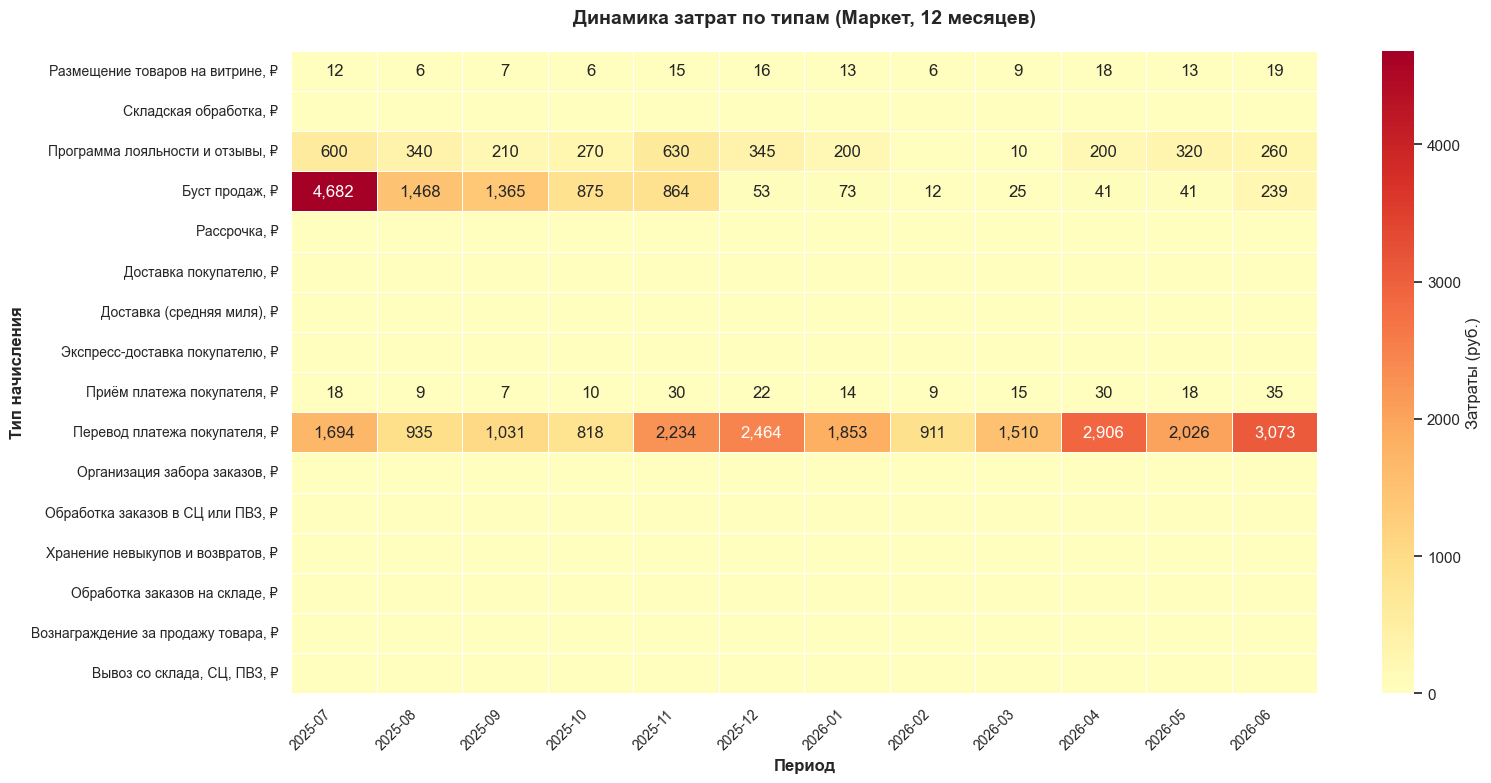

In [72]:
# Визуализируем динамику затрат
market_fees_period = market_margin_df_12m.groupby('period')[market_fees_list].sum().T

rename_map = {v: k for k, v in margin_cols.items()}
market_fees_period = market_fees_period.rename(index=rename_map)

heatmap_fees(market_fees_period, 'Динамика затрат по типам (Маркет, 12 месяцев)')

**Суммарные сборы за 12 месяцев: 34 934 ₽**

| Статья | Сумма, ₽ | Доля, % |
|:---|:---|:---|
| Перевод платежа покупателя | 21 455 | 61.4% |
| Буст продаж | 9 738 | 27.9% |
| Программа лояльности и отзывы | 3 385 | 9.7% |
| Приём платежа покупателя | 216 | 0.6% |
| Размещение товаров на витрине | 140 | 0.4% |
| **ИТОГО** | **34 934** | **100%** |

**Статьи с нулевыми затратами (льготы НКО):**
- Вознаграждение за продажу товара (комиссия) — 0 ₽
- Доставка покупателю (все виды) — 0 ₽
- Складская обработка — 0 ₽
- Хранение невыкупов и возвратов — 0 ₽
- Вывоз со склада — 0 ₽
- Обработка заказов в ПВЗ — 0 ₽
- Рассрочка — 0 ₽
- Организация забора заказов — 0 ₽

**Ключевые выводы:**

1. **Логистика и хранение полностью субсидируются.** 11 из 16 статей затрат равны нулю. Это ключевое конкурентное преимущество Яндекс Маркета перед Ozon.

2. **Основные затраты — банковские операции (62%).** Перевод и приём платежа — неизбежные издержки, не зависящие от продавца.

3. **Буст продаж — 28% затрат.** Единственный управляемый инструмент продвижения. Затраты имеют нисходящий тренд: с 4 682 ₽ в июле 2025 до минимальных значений в 2026 году (12–239 ₽), что свидетельствует об отказе от платного продвижения.

4. **Доля сборов от выручки — 2.4%.** Это в 7.8 раз ниже, чем на Ozon (18.8%). Маркет — экономически предпочтительная площадка для всех категорий товаров.

**Зона контроля:** Буст продаж. При текущем органическом трафике его эффективность неочевидна. Рекомендуется провести оценку ROI по SKU, участвовавшим в продвижении.

## 12. Выводы и рекомендации бизнесу

### 12.1. Ключевые выводы

1. Яндекс Маркет — основная площадка с кратно лучшей экономикой

Выручка в 2.5 раза выше, прибыль — в 3.6 раза, сборы (в процентном выражении) — в 7.8 раз ниже, чем на Ozon. Логистика и хранение полностью субсидируются площадкой: 11 из 16 статей затрат равны нулю. Маржинальность — 54% против 37.6% на Ozon. Расширение ассортимента на Маркете экономически безопасно — длительное хранение не штрафуется.

2. Ozon — площадка с высокими операционными рисками

Основная утечка прибыли на Ozon — хранение (31.2% всех сборов) и логистика (25.7%). Причина — превышение 120 дней бесплатного хранения. Товары с низкой оборачиваемостью накапливают затраты, которые в ряде случаев превышают маржу от продажи. Убыточные SKU (8 позиций) съедают 19% общей прибыли.

3. По текущим данным нельзя оценить эластичность спроса.

В текущих данных не обнаружена выраженная линейная связь между изменением средней цены реализации и объемом продаж (корреляция -0,37 на Ozon и -0,07 на Маркете). Однако отсутствие сильной корреляции не означает отсутствие эластичности: на спрос одновременно влияют смешивающие факторы (событийная сезонность, наличие товара на складе (OOS), внутренние алгоритмические акции площадок). Экстремальный разброс цен (до 617% на Ozon) — следствие вынужденных распродаж для остановки затрат на хранение, а не управленческого ценообразования. Органический трафик и событийный календарь — основные драйверы спроса.

4. Спрос привязан к событийному календарю донорства

Пики продаж на обеих площадках приходятся на апрель (Национальный день донора) и июнь (Всемирный день донора). На Маркете дополнительный пик — предновогодний Q4. Ошибка управления остатками в конце 2025 года (паническая распродажа → дефицит в декабре) привела к упущенной выручке.

5. Ассортиментное ядро — 9 SKU на Ozon и 20 на Маркете

Ядро генерирует основную прибыль: браслеты, значки, брелоки, жмяка-эспандер. На Ozon ядро дает 82% прибыли при 43.5% ассортимента. На Маркете убыточных SKU нет — все категории прибыльны.

### 12.2. Рекомендации бизнесу

**По площадкам**<br>
Яндекс Маркет — приоритетная площадка для масштабирования. Низкие сборы (2.4% от выручки) и отсутствие платы за хранение позволяют размещать любые SKU без риска накопления издержек. Расширение ассортимента на Маркете перед событийными пиками (апрель, июнь, ноябрь-декабрь) даст максимальный прирост выручки.

Ozon — использовать только для проверенных высокомаржинальных товаров с быстрой оборачиваемостью. Т Для категорий, склонных к накоплению остатков (футболки, шопперы, термостаканы), оставлять на Ozon только ходовые размеры и цвета (ядро). Медленно оборачивающиеся вариации переносить на Маркет, где хранение бесплатно. Жестко пресекать распродажи ниже себестоимости: при достижении 90 дней хранения запускать контролируемую уценку, не дожидаясь накопления критических затрат.

**По ассортименту**<br>

| Рекомендация | Ozon | Яндекс Маркет | Смысл |
|--------------|------|---------------|-------|
| **Ядро (держать в наличии)** | 9 SKU | 20 SKU | Пополнять по факту продаж, не допускать out-of-stock |
| **Повысить цену (тест)** | 10 SKU | 9 SKU | Поднять на 10–15%, мониторить продажи 4 недели |
| **Контроль остатков / Вывод вариаций** | 8 SKU | — | Не выводить категорию целиком, но убрать с Ozon медленно оборачивающиеся размеры/цвета (перенести на Маркет), чтобы избежать повторения сценария Q4 2025 |
| **Ассортимент (1–2 шт.)** | 37 SKU | 74 SKU | Держать минимальный остаток, не завозить больше |
| **Итого SKU** | **64** | **103** | |

**Источник:** раздел 8. Сегментация товаров (Ozon, Маркет). Полные списки SKU — в файлах `озон_рекомендации_SKU.xlsx` и `маркет_рекомендации_SKU.xlsx`.

**По управлению остатками (Ozon)**<br>
Внедрить систему раннего оповещения. Товары, которые не продаются более 30 дней, должны вывозиться со склада или попадать в список на распродажу. Это позволит запускать контролируемую уценку до того, как затраты на хранение превысят потери от снижения цены.

**По ценообразованию**<br>
Прекратить использовать снижение цены как инструмент управления спросом. Исторические данные не показывают выраженной линейной связи между ценой и объемом продаж (корреляция -0.37 на Ozon, -0.07 на Маркете). С учетом влияния других факторов этого недостаточно для оценки эластичности, однако факт остается: изменение цены не приводит к росту продаж. Фокус — на управлении остатками и пополнении ассортимента перед событийными пиками.

### 12.3. Ограничения анализа

1. **Отсутствие истории цен в корзине.** API площадок не позволяет выгрузить цену, которую видел покупатель до персональных скидок. Анализ ценообразования построен на средней цене реализации (ASP) в разрезе месяцев, что может сглаживать внутримесячные колебания.

2. **Отсутствие исторических данных по складским остаткам.** Невозможно точно оценить периоды out-of-stock (OOS) и упущенную выручку. Низкие продажи по SKU могут быть следствием как отсутствия спроса, так и отсутствия товара на складе.

3. **Расчетное распределение сборов на Маркете.** Отчеты не содержат детализации сервисных расходов по SKU внутри мульти-товарного заказа. Распределение выполнено пропорционально выручке товара в заказе. Для агрегированной аналитики метод корректен, но может содержать погрешность для отдельных заказов.

4. **Отсутствие данных по атрибуции рекламы.** Оценить влияние рекламных инструментов на финансовый результат невозможно из-за отсутствия данных о том, какие заказы пришли с рекламы, а какие — органически. При текущем уровне затрат (< 1% от выручки) влияние рекламы статистически неразличимо.

5. **Низкая частота продаж для большинства SKU.** Для товаров с 1–5 продажами в месяц корреляционный анализ цены и объема невозможен из-за статистической незначимости выборки. Выводы по эластичности спроса релевантны только для SKU с высоким и стабильным спросом (интенсивность ≥ 3 шт./мес., активность ≥ 8 месяцев).

### 12.4. Приоритетные шаги

| № | Действие | Срок | Ожидаемый эффект |
|---|----------|------|------------------|
| 1 | Перенести убыточные SKU (футболки, шопперы, термостаканы) с Ozon на Маркет | 1 месяц | Прекращение убытка (8 SKU съедают 19% прибыли Ozon) |
| 2 | Внедрить систему раннего оповещения по остаткам на Ozon (30 дней без продаж → распродажа) | 1 месяц | Снижение затрат на хранение (31% сборов Ozon) |
| 3 | Провести тест повышения цены на 10 SKU Ozon и 9 SKU Маркет | 2 месяца | Рост маржинальности без потери объема |
| 4 | Расширить ассортимент на Маркете перед событийными пиками (апрель, июнь, ноябрь-декабрь) | - | Рост выручки за счет увеличения активных SKU |
| 5 | Установить жесткий порог минимальной цены (cogs + avg_fees + 5%) | 1 месяц | Защита от убыточных продаж |


**Вывод**<br>
Ключевой рычаг управления прибылью — не ценообразование, а управление складскими остатками и ассортиментной матрицей. Маркет — предпочтительная площадка для масштабирования. Ozon требует жесткого контроля оборачиваемости, иначе льготная комиссия 1% нивелируется затратами на хранение и логистику.